# IRB risk parameters against outcomes: EU CR9 and CR6, 2025-Q4

**Reference date:** 31 December 2025
**Templates:** EU CR9 (`K_29.00`, Hub `TableVID 6292`) and EU CR6 (`K_26.00.a`, `TableVID 6295`)
**Population:** highest-EEA banking groups in the EBA Pillar 3 Data Hub that filed CR9

Template EU CR6 discloses the parameters a bank *assigns* — PD, LGD and conversion factors.
Template **EU CR9 discloses what actually happened** — how many obligors defaulted, and how that
compares with the PD estimate. This notebook extracts both, joins them on bank × exposure class ×
PD band, and compares estimate against outcome per bank and per exposure class.

**The comparison is possible for PD and not for LGD.** CR9 backtests PD only; nothing in the
disclosure framework reports a realised loss rate against an estimated LGD. So sections 5.1, 6.1
to 6.4 are a genuine backtest, while sections 5.2, 6.5 and 6.6 describe the *distribution* of
disclosed LGD — where the AIRB/FIRB split carries the signal, because foundation LGD is prescribed
by the CRR rather than estimated.

| | Template · column | What it is |
|---|---|---|
| **Estimated** | CR9 `0050` Average PD at the disclosure date | the estimate, obligor-weighted |
| | CR9 `0040` Exposure weighted average PD | the estimate, exposure-weighted (as CR6) |
| | CR6 `0070` **Exposure weighted average LGD** | the loss estimate — no realised counterpart |
| | CR6 `0030` Exposure weighted average conversion factor | the other own-estimate parameter |
| **Realised** | CR9 `0060` Average historical annual default rate | outcome, ≥ 5 most recent years |
| | CR9 `0030` Observed average default rate | outcome, over the available dataset |
| | CR9 `0020 / 0010` defaulted ÷ obligors | outcome, the one year to the disclosure date |
| **Loss** | CR6 `0110` Expected loss amount | regulatory estimate |
| | CR6 `0120` Value adjustments and provisions | the accounting amount booked against it |

The headline comparison is **`0050` against `0060`**: both are obligor-count based, so they are
like for like. Exposure-weighted PD (`0040`) is carried through as a robustness check but is not
directly comparable to an obligor-count default rate.

A code-free walkthrough of the whole calculation - every filter, every exclusion and every
weighting, including why the `100 (Default)` band is left out - is in **Appendix A** at the end.

> **Live notebook.** Every table is read from the Hub at execution time. Counts and the bank
> population are whatever the Hub publishes when you run it, not a saved snapshot.

## Sources

**Hub** — [EBA Pillar 3 Data Hub](https://www.eba.europa.eu/risk-and-data-analysis/pillar-3-data-hub)
· [public report](https://edap-public.eba.europa.eu/Report/index/MTE1) ·
per-bank source filings are linked in the detail table in section 7.

**Regulatory**

- [Implementing Regulation (EU) 2024/3172](https://eur-lex.europa.eu/eli/reg_impl/2024/3172/oj/eng)
  — the ITS in force for this reference date. Contains the CR9 **template**; it carries **no
  instruction annexes**.
- [Implementing Regulation (EU) 2021/637](https://eur-lex.europa.eu/eli/reg_impl/2021/637/oj/eng),
  **Annex XXII** — the operative **instructions** for CR9, quoted verbatim in section 1.
- [Regulation (EU) No 575/2013 (CRR)](https://eur-lex.europa.eu/eli/reg/2013/575/oj/eng)
  — Article 178 (definition of default), Article 4(1)(78) (one-year default rate),
  Article 172(1)(e) (obligor grades), Article 180(1)(f) (ECAI-based PD, template CR9.1).

## 1. What the columns mean

The current ITS, [(EU) 2024/3172](https://eur-lex.europa.eu/eli/reg_impl/2024/3172/oj/eng),
reproduces the CR9 template but **contains no instructions**: its correlation table (Annex II)
maps only the template annexes of the repealed
[(EU) 2021/637](https://eur-lex.europa.eu/eli/reg_impl/2021/637/oj/eng) into its single Annex I.
The narrative instruction annexes have no successor, so the operative definitions remain those in
**2021/637 Annex XXII** (OJ L 136, 21.4.2021, pp. 224–225). The Hub's own metadata does not help:
DPM metric `(qNNL) Default rate` has an empty description.

Verbatim, for the two columns this notebook compares:

> **h — Average historical annual default rate (%)**
> The simple average of the annual default rate of at least five most recent years (obligors at
> the beginning of each year that are defaulted during that year / total number of obligors at the
> beginning of the year)
>
> The institution may use a longer historical period that is consistent with the institution's
> actual risk management practices. If the institution uses a longer historical period they shall
> explain and clarify this in the accompanying narrative to the template.

> **g — Average PD at the disclosure date (%)**
> Arithmetic average of PD at the beginning of the disclosure period of the obligors that fall
> within the bucket of the fixed PD range and counted in d (average weighted by the number of
> obligors)

And for the inputs and the alternative realised measure:

> **e — Observed average default rate**
> Arithmetic average of one-year default rates as defined in point (78) of Article 4(1) CRR,
> observed within the available dataset. […] the denominator consists of the number of
> non-defaulted obligors with any credit obligation observed at the beginning of the one-year
> observation period […] the numerator includes all those obligors considered in the denominator
> that had at least one default event during the one-year observation period. Institutions shall
> choose an appropriate approach between an approach based on overlapping one-year time windows,
> and an approach based on non-overlapping one-year time windows.

> **c, d — Number of obligors at the end of the previous year**
> […] the number of legal entities or obligors allocated to each bucket of the fixed PD range by
> the end of the previous year, which were separately rated, regardless of the number of different
> loans or exposures granted. […] of which number of obligors that defaulted during the year
> preceding the disclosure date […] Defaults shall be determined in accordance with Article 178
> CRR. Each defaulted obligor shall be counted only once in the numerator and denominator of the
> one-year default rate calculation, even if the obligor defaulted more than once.

**Three consequences for the analysis.**

1. `h` and `e` differ only in the observation window: `h` is at least the five most recent
   years, `e` is the whole available dataset with the institution's choice of overlapping or
   non-overlapping windows. Neither is exposure-weighted.
2. `h` is *not* the long-run average default rate used to calibrate PD. It is a recent-window
   average, and the window length varies by bank. Where a bank uses more than five years the
   explanation sits in the accompanying-narrative table `K_00.02`, row `0260`
   (`(qANH) Accompanying narrative EU CR9`) — a separate Hub table.
3. Column `g` is defined as the average PD of the obligors "counted in **d**", i.e. read
   literally, the *defaulted* obligors only. The column name and its position as the calibration
   benchmark point the other way. This notebook uses `g` as the predicted measure because it is
   obligor-weighted like the default rates, and reports `f` alongside it so the reader can see
   whether the choice matters.

In [1]:
# 2. Environment and reproducibility metadata
import json
import time
import uuid

import duckdb
import pandas as pd
import requests
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

REFERENCE_DATE = pd.Timestamp("2025-12-31")
EXTRACTED_AT_UTC = pd.Timestamp.now(tz="UTC")

P3DH_URL = "https://edap-public.eba.europa.eu/Report/index/MTE1?rhversion=20260722160254-2"
P3DH_REPORT = "f0de0c7c-c532-4b55-9bef-da99423cf672"
P3DH_DB = "d9c4b646-c0e6-4b73-887f-8f6702855ae2"
P3DH_MODEL = 5131315
P3DH_QUERY = (
    "https://wabi-west-europe-d-primary-redirect.analysis.windows.net"
    "/explore/querydata?synchronous=true"
)
USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 Chrome/127.0 Safari/537.36"
)

CR9_TEMPLATE = "K_29.00"
CR9_TABLE_VID = 6292
CR9_COLUMNS = ["0010", "0020", "0030", "0040", "0050", "0060"]

# CR6 carries the estimated risk parameters. LGD exists nowhere else in the credit-risk
# framework: K_26.00.b, the CR6 totals table, has no LGD or PD column at all.
CR6_TEMPLATE = "K_26.00"
CR6_TABLE_CODE = "K_26.00.a"
CR6_TABLE_VID = 6295
CR6_COLUMNS = ["0030", "0040", "0050", "0070", "0110", "0120"]

# The Hub truncates a single semantic query at 30,000 rows. CR9 holds ~48,000 facts, so the
# extraction is paginated one reported column at a time; each slice stays well under the cap.
QUERY_ROW_LIMIT = 29_000

print(f"Reference date:      {REFERENCE_DATE.date()}")
print(f"Extraction started:  {EXTRACTED_AT_UTC:%Y-%m-%d %H:%M:%S %Z}")
print(f"Template / TableVID: {CR9_TEMPLATE} / {CR9_TABLE_VID}")

Reference date:      2025-12-31
Extraction started:  2026-08-02 19:29:14 UTC
Template / TableVID: K_29.00 / 6292


## 3. Read-only Hub extraction

The connector fetches the public embed token from the report page and submits Power BI
semantic queries.
Listing the entities in `From` makes the engine resolve the model relationships, so the
eight-entity join is written as a flat list of aliases. All filtering, mapping and aggregation
happens afterwards in DuckDB SQL.

In [2]:
# 3.1 Decode the EBA public Power BI semantic-query response
def get_public_embed_token(attempts=6, pause_seconds=5.0):
    """Return the temporary public token embedded in the EBA report page."""
    last_error = None
    for _ in range(attempts):
        try:
            session = requests.Session()
            session.headers["User-Agent"] = USER_AGENT
            response = session.get(P3DH_URL, allow_redirects=True, timeout=120)
            response.raise_for_status()
            html = response.text
            token_start = html.find("H4sI")
            if token_start >= 0:
                return html[token_start:html.index('"', token_start)]
            last_error = f"report page contained no token ({len(html):,} bytes)"
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(pause_seconds)
    raise RuntimeError(f"Unable to obtain the public EBA embed token: {last_error}")


def select_column(alias, property_name):
    return {
        "Column": {
            "Expression": {"SourceRef": {"Source": alias}},
            "Property": property_name,
        },
        "Name": f"{alias}.{property_name}",
    }


def select_measure(alias, property_name):
    return {
        "Measure": {
            "Expression": {"SourceRef": {"Source": alias}},
            "Property": property_name,
        },
        "Name": f"{alias}.{property_name}",
    }


def equals_filter(alias, property_name, literal):
    return {
        "Condition": {
            "Comparison": {
                "ComparisonKind": 0,
                "Left": {
                    "Column": {
                        "Expression": {"SourceRef": {"Source": alias}},
                        "Property": property_name,
                    }
                },
                "Right": {"Literal": {"Value": literal}},
            }
        }
    }


def decode_powerbi_rows(response_text):
    """Expand Power BI dictionary and repeat-mask encoding into ordinary rows."""
    payload = json.loads(response_text.lstrip("﻿"))
    shapes = payload["results"][0]["result"]["data"].get("dsr", {}).get("DataShapes")
    if shapes and "odata.error" in shapes[0]:
        raise RuntimeError(shapes[0]["odata.error"]["message"]["value"])

    decoded_rows = []
    for result in payload["results"]:
        data_set_result = result["result"]["data"].get("dsr")
        if not data_set_result:
            continue
        for data_set in data_set_result.get("DS", []):
            dictionaries = data_set.get("ValueDicts", {})
            column_specs = None
            for phase in data_set.get("PH", []):
                for encoded_rows in phase.values():
                    previous_row = []
                    for encoded in encoded_rows:
                        if "S" in encoded:
                            column_specs = encoded["S"]
                        if column_specs is None:
                            continue
                        repeat_mask = encoded.get("R", 0)
                        null_mask = encoded.get("Ø", 0)
                        decoded = []

                        def dictionary_value(value, spec):
                            name = spec.get("DN")
                            if (
                                name in dictionaries
                                and isinstance(value, int)
                                and 0 <= value < len(dictionaries[name])
                            ):
                                return dictionaries[name][value]
                            return value

                        if "C" in encoded:
                            values = encoded["C"]
                            value_index = 0
                            for position, spec in enumerate(column_specs):
                                if null_mask >> position & 1:
                                    decoded.append(None)
                                elif repeat_mask >> position & 1 or value_index >= len(values):
                                    decoded.append(
                                        previous_row[position]
                                        if position < len(previous_row)
                                        else None
                                    )
                                else:
                                    decoded.append(dictionary_value(values[value_index], spec))
                                    value_index += 1
                        else:
                            for position, spec in enumerate(column_specs):
                                key = spec.get("N", f"G{position}")
                                if key in encoded:
                                    decoded.append(dictionary_value(encoded[key], spec))
                                elif null_mask >> position & 1:
                                    decoded.append(None)
                                else:
                                    decoded.append(
                                        previous_row[position]
                                        if position < len(previous_row)
                                        else None
                                    )
                        decoded_rows.append(decoded)
                        previous_row = decoded
    return decoded_rows


def query_public_p3dh(token, sources, selections, filters, row_limit=QUERY_ROW_LIMIT):
    """Submit one read-only semantic query to the public P3DH model."""
    semantic_query = {
        "Version": 2,
        "From": sources,
        "Select": selections,
        "Where": filters,
    }
    body = {
        "version": "1.0.0",
        "queries": [{
            "Query": {
                "Commands": [{
                    "SemanticQueryDataShapeCommand": {
                        "Query": semantic_query,
                        "Binding": {
                            "Primary": {
                                "Groupings": [{
                                    "Projections": list(range(len(selections)))
                                }]
                            },
                            "DataReduction": {
                                "DataVolume": 4,
                                "Primary": {"Window": {"Count": row_limit}},
                            },
                            "Version": 1,
                        },
                    }
                }],
                "QueryId": "",
                "ApplicationContext": {
                    "DatasetId": P3DH_DB,
                    "Sources": [{"ReportId": P3DH_REPORT, "VisualId": "v"}],
                },
            }
        }],
        "cancelQueries": [],
        "modelId": P3DH_MODEL,
    }
    headers = {
        "Authorization": f"EmbedToken {token}",
        "Content-Type": "application/json;charset=UTF-8",
        "X-PowerBI-ResourceKey": P3DH_REPORT,
        "ActivityId": str(uuid.uuid4()),
        "RequestId": str(uuid.uuid4()),
    }
    response = requests.post(P3DH_QUERY, headers=headers, json=body, timeout=300)
    response.raise_for_status()
    return decode_powerbi_rows(response.content.decode("utf-8-sig"))

### 3.2 The eight-entity join, paginated by reported column

CR9 is an **open table**: every fact sits at a row (PD band) and column coordinate, while the
exposure class and the with/without-own-estimates distinction live in the open-table member,
addressed by `UniqueKeyID` and resolved through `dm_TableKey`. Without that join, all facts for a
bank collapse into one indistinguishable coordinate.

The one query that would return everything is truncated by the Hub at 30,000 rows, so the
extraction runs once per reported column and the slices are concatenated. Each slice is checked
against the cap so a silent truncation cannot pass unnoticed.

In [3]:
# 3.2 Retrieve row metadata, open-table members and the CR9 facts
token = get_public_embed_token()

CR9_SOURCES = [
    {"Name": alias, "Entity": entity, "Type": 0}
    for alias, entity in [
        ("e", "dm_Entity"),
        ("t", "dm_Template"),
        ("i", "dm_ReportInstance"),
        ("r", "dm_Row"),
        ("c", "dm_Column"),
        ("f", "fact_Value"),
        ("v", "Measure P3"),
        ("k", "dm_TableKey"),
    ]
]
CR9_SELECTIONS = [
    select_column("e", "ENT_NAM"),
    select_column("e", "EntityCode"),
    select_column("e", "Country"),
    select_column("e", "InstitutionType"),
    select_column("e", "IS_HIG_LEV_EEA"),
    select_column("i", "InstanceID"),
    select_column("i", "IsCurrent"),
    select_column("i", "IsAccepted"),
    select_column("i", "Status"),
    select_column("i", "Report File Link"),
    select_column("r", "HeaderCode"),
    select_column("c", "HeaderCode"),
    select_column("f", "UniqueKeyID"),
    select_column("k", "KeyDescriptor"),
    select_column("k", "SheetKey1"),
    select_measure("v", "FactValue"),
]
CR9_COLUMN_NAMES = [
    "bank", "lei", "country", "institution_type", "is_highest_eea", "instance_id",
    "is_current", "is_accepted", "status", "source_link", "row_code", "column_code",
    "unique_key_id", "key_descriptor", "member", "fact_value",
]


def load_pd_bands():
    fields = ["HeaderCode", "HeaderLabel", "Order"]
    rows = query_public_p3dh(
        token,
        [{"Name": "r", "Entity": "dm_Row", "Type": 0}],
        [select_column("r", field) for field in fields],
        [equals_filter("r", "TableVID", f"'{CR9_TABLE_VID}'")],
        row_limit=1_000,
    )
    return pd.DataFrame(rows, columns=["row_code", "band_label", "band_order"])


def load_members():
    fields = ["UniqueKeyID", "KeyDescriptor", "SheetKey1"]
    rows = query_public_p3dh(
        token,
        [{"Name": "k", "Entity": "dm_TableKey", "Type": 0}],
        [select_column("k", field) for field in fields],
        [equals_filter("k", "TableVID", f"'{CR9_TABLE_VID}'")],
        row_limit=1_000,
    )
    return pd.DataFrame(rows, columns=["unique_key_id", "key_descriptor", "member"])


def load_cr9_column(column_code):
    rows = query_public_p3dh(
        token,
        CR9_SOURCES,
        CR9_SELECTIONS,
        [
            equals_filter("t", "TemplateCode", f"'{CR9_TEMPLATE}'"),
            equals_filter(
                "i", "ReferenceDate",
                f"datetime'{REFERENCE_DATE:%Y-%m-%d}T00:00:00'",
            ),
            equals_filter("i", "IsCurrent", "1L"),
            equals_filter("c", "HeaderCode", f"'{column_code}'"),
        ],
    )
    if len(rows) >= QUERY_ROW_LIMIT:
        raise RuntimeError(
            f"column {column_code} returned {len(rows):,} rows and may be truncated; "
            "paginate further before trusting the result"
        )
    return pd.DataFrame(rows, columns=CR9_COLUMN_NAMES)


p3_cr9_bands = load_pd_bands()
p3_cr9_members = load_members()
p3_cr9_raw = pd.concat(
    [load_cr9_column(column) for column in CR9_COLUMNS], ignore_index=True
)

print(f"CR9 PD-band metadata:  {len(p3_cr9_bands):,} rows")
print(f"CR9 open-table members:{len(p3_cr9_members):,}")
print(f"Raw 2025-Q4 CR9 facts: {len(p3_cr9_raw):,} across {p3_cr9_raw['lei'].nunique()} LEIs")

CR9 PD-band metadata:  17 rows
CR9 open-table members:20
Raw 2025-Q4 CR9 facts: 47,793 across 85 LEIs


### 3.3 The estimated risk parameters: CR6

CR9 holds outcomes and the PD estimate. **LGD is not in CR9** — it is disclosed in EU CR6
(`K_26.00.a`, `TableVID 6295`), column `0070`, and nowhere else in the credit-risk framework.
Across the whole public model only five columns mention LGD, recovery or write-off: CR6 column
`0070`, the two CCR4 tables' column `0040` (counterparty credit risk), CR1's accumulated partial
write-off and CR2a's net accumulated recoveries.

`K_26.00.b`, the CR6 *totals* table, has no LGD column and no PD column, so LGD exists only at
PD-band × exposure-class grain — there is no bank-level LGD figure to read off.

CR6.a uses the same fixed PD scale and the same open-table members as CR9, so the two join
cleanly on bank × member × PD band. This extraction takes six more columns:

| Column | Field | Role here |
|---|---|---|
| `0030` | Exposure weighted average conversion factor | the other own-estimate parameter separating AIRB from FIRB |
| `0040` | Exposure value post CCF and CRM | EAD, the weight for every exposure-weighted average |
| `0050` | Exposure weighted average PD | scale anchor, and a cross-check on the CR9 PD |
| `0070` | **Exposure weighted average LGD** | the estimated loss parameter |
| `0110` | Expected loss amount | regulatory expected loss |
| `0120` | Value adjustments and provisions | the accounting outcome against it |

In [4]:
# 3.3 CR6 risk parameters, paginated the same way
CR6_SOURCES = [
    {"Name": alias, "Entity": entity, "Type": 0}
    for alias, entity in [
        ("e", "dm_Entity"), ("t", "dm_Template"), ("i", "dm_ReportInstance"),
        ("tb", "dm_Table"), ("r", "dm_Row"), ("c", "dm_Column"),
        ("f", "fact_Value"), ("v", "Measure P3"), ("k", "dm_TableKey"),
    ]
]


def load_cr6_column(column_code):
    rows = query_public_p3dh(
        token,
        CR6_SOURCES,
        CR9_SELECTIONS,
        [
            equals_filter("t", "TemplateCode", f"'{CR6_TEMPLATE}'"),
            equals_filter("tb", "TableCode", f"'{CR6_TABLE_CODE}'"),
            equals_filter(
                "i", "ReferenceDate",
                f"datetime'{REFERENCE_DATE:%Y-%m-%d}T00:00:00'",
            ),
            equals_filter("i", "IsCurrent", "1L"),
            equals_filter("c", "HeaderCode", f"'{column_code}'"),
        ],
    )
    if len(rows) >= QUERY_ROW_LIMIT:
        raise RuntimeError(
            f"CR6 column {column_code} returned {len(rows):,} rows and may be truncated"
        )
    return pd.DataFrame(rows, columns=CR9_COLUMN_NAMES)


p3_cr6_raw = pd.concat(
    [load_cr6_column(column) for column in CR6_COLUMNS], ignore_index=True
)
print(f"Raw 2025-Q4 CR6 facts: {len(p3_cr6_raw):,} across {p3_cr6_raw['lei'].nunique()} LEIs")

Raw 2025-Q4 CR6 facts: 58,534 across 96 LEIs


## 4. SQL transformation

Five things have to be right before a realised rate can be compared with a predicted one. Each is
a documented Hub trap, and each is handled explicitly in the SQL below.

| # | Trap | Treatment |
|---|---|---|
| 1 | **The PD bands are hierarchical, not a partition.** `0010` contains `0020`+`0030`; `0070` contains `0080`+`0090`; `0100` contains `0110`+`0120`; `0130` contains `0140`+`0150`+`0160`. All but one bank in this dataset file both levels, so summing all rows double counts. | Keep only the seven coarse non-default bands, which every bank reports. |
| 2 | **The `100 (Default)` band is not a calibration observation.** Row `0170` holds obligors already in default, PD 100%. | Excluded from every comparison; retained in the raw export. |
| 3 | **Percentage scale is not consistent across banks.** Most file ratios (`0.0137`), a few file percentage points (`1.37`). | Resolved per bank, anchored on row `0170`: an average PD for the default band must read `1` under the ratio convention and `100` under points. Where the anchor is missing, any value above 1 is proof of points, because a rate cannot exceed 1 as a ratio. |
| 4 | **One open key does not resolve.** `UniqueKeyID 161333573377302602` has no `dm_TableKey` row — the same gap the IRB notebook documents. It carries 3,000+ facts across 40 banks, so dropping it would silently remove most FIRB corporate exposure. | Single explicit fallback to `Corporates - Other without own estimates of LGD or conversion factors`, flagged in the output. |
| 5 | **Resubmissions.** `IsAccepted` alone keeps superseded instances. | `ReferenceDate` + `IsCurrent` + `IsAccepted` + `Status = 'Accepted'`, plus the highest-EEA group filter. |

Aggregation from PD band to bank × exposure class:

```text
obligors        = sum(column 0010)                         over the seven coarse bands
defaulted       = sum(column 0020)
realised 1y DR  = 100 * defaulted / obligors               pooled, not an average of averages
realised hist DR= obligor-weighted mean of column 0060
predicted PD    = obligor-weighted mean of column 0050
predicted EW PD = obligor-weighted mean of column 0040     robustness check only
```

Rates are pooled from counts rather than averaged across bands wherever the counts allow it,
because an unweighted average of band-level rates is not a portfolio rate.

**Cells that cannot carry a comparison are flagged, not repaired.** Most are simply absent: the
bank reports obligor counts for a class but leaves the PD or the historical default rate blank.
A smaller group reports a figure that cannot be a rate at all — a historical default rate above
100%, or exactly 100% against a one-year realised rate near zero, the signature of the
percentage-scale ambiguity above applied inconsistently across columns within one filing.
Neither can be resolved from the disclosure alone, so every such cell carries a
`dq_exception` flag and is excluded from every chart and summary that follows.

In [5]:
# 4. Register the raw Hub extracts; no analytical pandas transformations occur
def repair_utf8_mojibake(value):
    """Repair labels that the public model exposes as UTF-8 decoded as Latin-1."""
    if value is None or not any(marker in value for marker in ("Ã", "Â")):
        return value
    try:
        return value.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return value


con = duckdb.connect()
con.create_function(
    "repair_utf8_mojibake",
    repair_utf8_mojibake,
    parameters=["VARCHAR"],
    return_type="VARCHAR",
)
con.register("p3_cr9_raw", p3_cr9_raw)
con.register("p3_cr6_raw", p3_cr6_raw)
con.register("p3_cr9_bands", p3_cr9_bands)
con.register("p3_cr9_members", p3_cr9_members)

SQL_TRANSFORM = r"""
-- The fixed PD scale. parent_code marks the coarse band each sub-band refines, so the
-- coarse bands are the ones with no parent. Row 0170 is the already-defaulted bucket.
CREATE OR REPLACE TABLE pd_band_map AS
SELECT * FROM (VALUES
    ('0010', NULL,   1, '0.00 to <0.15' ),
    ('0020', '0010', 0, '0.00 to <0.10' ),
    ('0030', '0010', 0, '0.10 to <0.15' ),
    ('0040', NULL,   2, '0.15 to <0.25' ),
    ('0050', NULL,   3, '0.25 to <0.50' ),
    ('0060', NULL,   4, '0.50 to <0.75' ),
    ('0070', NULL,   5, '0.75 to <2.5'  ),
    ('0080', '0070', 0, '0.75 to <1.75' ),
    ('0090', '0070', 0, '1.75 to <2.5'  ),
    ('0100', NULL,   6, '2.5 to <10'    ),
    ('0110', '0100', 0, '2.5 to <5'     ),
    ('0120', '0100', 0, '5 to <10'      ),
    ('0130', NULL,   7, '10 to <100'    ),
    ('0140', '0130', 0, '10 to <20'     ),
    ('0150', '0130', 0, '20 to <30'     ),
    ('0160', '0130', 0, '30 to <100'    ),
    ('0170', NULL,   8, '100 (Default)' ),
    -- CR6 only, and never aggregated: row 0180 is the bank's own subtotal for the exposure
    -- class. It is carried through purely to reconcile our weighted averages against it.
    ('0180', NULL,   9, 'Subtotal (exposure class)')
) AS t(row_code, parent_code, coarse_order, band_label);

-- Member text -> exposure class. The needles are disjoint, so order only decides ties.
-- "corporates - other" cannot match a purchased-receivables or specialised-lending member,
-- and the three retail needles are likewise mutually exclusive.
CREATE OR REPLACE TABLE class_map AS
SELECT * FROM (VALUES
    ( 1, 'central governments',                       'Central govts & central banks'     ),
    ( 2, 'regional governments',                      'Regional/local govts'              ),
    ( 3, 'public sector entities',                    'Public-sector entities'            ),
    ( 4, 'institutions',                              'Institutions'                      ),
    ( 5, 'corporates - other',                        'Corporates - general'              ),
    ( 6, 'corporates - specialised lending',          'Corporates - specialised lending'  ),
    ( 7, 'corporates - purchased receivables',        'Corporates - purchased receivables'),
    ( 8, 'retail - qualifying revolving',             'Retail - QRRE'                     ),
    ( 9, 'retail exposures - secured by residential', 'Retail - residential RE'           ),
    (10, 'retail exposures - purchased receivables',  'Retail - purchased receivables'    ),
    (11, 'retail exposures - other',                  'Retail - other'                    ),
    (12, 'collective investment undertakings',        'CIU'                               )
) AS t(class_order, needle, asset_class);

-- The single documented open key with no dm_TableKey row. Source: the institution's own
-- filing identifies it as eba_qAE:qx2012.
CREATE OR REPLACE TABLE cr9_key_fallback AS
SELECT * FROM (VALUES
    ('161333573377302602',
     'Corporates - Other without own estimates of LGD or conversion factors')
) AS t(unique_key_id, member);

-- Which columns are percentages, per template. Everything else is a count or an amount and
-- must never be rescaled.
CREATE OR REPLACE TABLE pct_column_map AS
SELECT * FROM (VALUES
    ('CR9', '0030'), ('CR9', '0040'), ('CR9', '0050'), ('CR9', '0060'),
    ('CR6', '0030'), ('CR6', '0050'), ('CR6', '0070')
) AS t(template, column_code);

-- Both templates, typed and restricted to the current accepted filing of a highest-EEA
-- group. CR6.a shares CR9's PD scale, open-table members and unresolved key, so one shape
-- serves both and the two join on bank / member / PD band later.
CREATE OR REPLACE TABLE irb_facts AS
WITH raw AS (
    SELECT 'CR9' AS template, * FROM p3_cr9_raw
    UNION ALL
    SELECT 'CR6' AS template, * FROM p3_cr6_raw
)
SELECT
    f.template,
    repair_utf8_mojibake(f.bank)                              AS bank,
    f.lei,
    f.country,
    f.institution_type,
    f.instance_id,
    f.source_link,
    lpad(CAST(f.row_code AS VARCHAR), 4, '0')                 AS row_code,
    lpad(CAST(f.column_code AS VARCHAR), 4, '0')              AS column_code,
    CAST(f.unique_key_id AS VARCHAR)                          AS unique_key_id,
    coalesce(f.member, b.member)                              AS member,
    f.member IS NULL AND b.member IS NOT NULL                 AS member_repaired,
    TRY_CAST(rtrim(CAST(f.fact_value AS VARCHAR), 'D') AS DOUBLE) AS raw_value
FROM raw AS f
LEFT JOIN cr9_key_fallback AS b
       ON CAST(f.unique_key_id AS VARCHAR) = b.unique_key_id
WHERE f.institution_type IN ('Large highest EEA', 'Other highest EEA')
  AND upper(CAST(f.is_highest_eea AS VARCHAR)) = 'YES'
  AND CAST(f.is_current  AS VARCHAR) = '1'
  AND CAST(f.is_accepted AS VARCHAR) = '1'
  AND f.status = 'Accepted'
  AND f.row_code IS NOT NULL
  AND f.column_code IS NOT NULL;

-- Percentage convention, decided per bank and per template. The default band anchors it: a
-- PD for "100 (Default)" reads 1 as a ratio and 100 as percentage points. The convention is
-- resolved separately for CR9 and CR6 rather than assumed to carry across a bank's filings.
CREATE OR REPLACE TABLE scale_convention AS
WITH anchor AS (
    SELECT template, lei, max(raw_value) AS anchor_value
    FROM irb_facts
    WHERE row_code = '0170'
      AND ((template = 'CR9' AND column_code IN ('0040', '0050'))
        OR (template = 'CR6' AND column_code = '0050'))
    GROUP BY template, lei
),
proof AS (
    SELECT f.template, f.lei, max(f.raw_value) AS max_value
    FROM irb_facts AS f
    JOIN pct_column_map AS p USING (template, column_code)
    GROUP BY f.template, f.lei
)
SELECT
    p.template,
    p.lei,
    CASE
        WHEN a.anchor_value >= 50               THEN 'percentage points'
        WHEN a.anchor_value BETWEEN 0.9 AND 1.1 THEN 'ratio'
        WHEN p.max_value > 1.001                THEN 'percentage points'
        ELSE 'ratio'
    END AS convention,
    CASE
        WHEN a.anchor_value >= 50               THEN 'default-band anchor reads 100'
        WHEN a.anchor_value BETWEEN 0.9 AND 1.1 THEN 'default-band anchor reads 1'
        WHEN p.max_value > 1.001                THEN 'a value above 1 cannot be a ratio'
        ELSE 'no anchor; every value at or below 1'
    END AS convention_basis
FROM proof AS p
LEFT JOIN anchor AS a USING (template, lei);

-- One row per bank / member / PD band carrying both templates: CR9 outcomes and CR6
-- parameters side by side. Grouping without the template column is what performs the join.
CREATE OR REPLACE TABLE irb_band AS
WITH scaled AS (
    SELECT
        f.*,
        CASE
            WHEN p.column_code IS NULL              THEN 1.0   -- a count or an amount
            WHEN s.convention = 'ratio'             THEN 100.0
            ELSE 1.0
        END AS factor
    FROM irb_facts AS f
    LEFT JOIN pct_column_map  AS p USING (template, column_code)
    LEFT JOIN scale_convention AS s USING (template, lei)
    WHERE f.member IS NOT NULL
)
SELECT
    b.lei,
    any_value(b.bank)                                                 AS bank,
    any_value(b.country)                                              AS country,
    any_value(b.source_link)                                          AS source_link,
    b.member,
    bool_or(b.member_repaired)                                        AS member_repaired,
    b.row_code,
    m.coarse_order,
    m.band_label,
    -- CR9: realised outcomes and the obligor-weighted PD
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR9' AND column_code = '0010')
                                                                      AS obligors,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR9' AND column_code = '0020')
                                                                      AS defaulted,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR9' AND column_code = '0030')
                                                                      AS observed_dr,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR9' AND column_code = '0040')
                                                                      AS cr9_ew_pd,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR9' AND column_code = '0050')
                                                                      AS avg_pd,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR9' AND column_code = '0060')
                                                                      AS hist_dr,
    -- CR6: the estimated parameters and the loss amounts
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR6' AND column_code = '0030')
                                                                      AS ccf,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR6' AND column_code = '0040')
                                                                      AS ead,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR6' AND column_code = '0050')
                                                                      AS cr6_ew_pd,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR6' AND column_code = '0070')
                                                                      AS lgd,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR6' AND column_code = '0110')
                                                                      AS expected_loss,
    max(b.raw_value * b.factor) FILTER (WHERE template = 'CR6' AND column_code = '0120')
                                                                      AS provisions
FROM scaled AS b
JOIN pd_band_map AS m USING (row_code)
GROUP BY b.lei, b.member, b.row_code, m.coarse_order, m.band_label;

-- Bank x exposure class x IRB variant, over the seven coarse non-default bands only.
-- PD and default rates are obligor-weighted; LGD and CCF are exposure-weighted, because
-- that is how CR6 defines them.
CREATE OR REPLACE TABLE cr9_class AS
WITH classified AS (
    SELECT
        b.*,
        c.asset_class,
        c.class_order,
        CASE
            WHEN lower(b.member) LIKE '%without own estimates%' THEN 'FIRB'
            WHEN lower(b.member) LIKE '%with own estimates%'    THEN 'AIRB'
            ELSE 'n/a'
        END AS irb_variant
    FROM irb_band AS b
    LEFT JOIN class_map AS c
           ON c.class_order = (
                  SELECT min(cm.class_order) FROM class_map AS cm
                  WHERE lower(b.member) LIKE '%' || cm.needle || '%'
              )
    WHERE b.coarse_order BETWEEN 1 AND 7
)
SELECT
    lei,
    any_value(bank)                                                  AS bank,
    any_value(country)                                               AS country,
    asset_class,
    min(class_order)                                                 AS class_order,
    string_agg(DISTINCT irb_variant, ' + ' ORDER BY irb_variant)     AS irb_variant,
    bool_or(member_repaired)                                         AS member_repaired,
    any_value(source_link)                                           AS source_link,
    count(*)                                                         AS band_cells,
    sum(obligors)                                                    AS obligors,
    sum(defaulted)                                                   AS defaulted,
    sum(ead)                                                         AS ead,
    sum(expected_loss)                                               AS expected_loss,
    sum(provisions)                                                  AS provisions,
    100.0 * sum(defaulted) / nullif(sum(obligors), 0)                AS realised_1y_dr,
    sum(hist_dr * obligors) FILTER (WHERE hist_dr IS NOT NULL)
        / nullif(sum(obligors) FILTER (WHERE hist_dr IS NOT NULL), 0) AS realised_hist_dr,
    sum(avg_pd * obligors) FILTER (WHERE avg_pd IS NOT NULL)
        / nullif(sum(obligors) FILTER (WHERE avg_pd IS NOT NULL), 0)  AS predicted_pd,
    sum(cr9_ew_pd * obligors) FILTER (WHERE cr9_ew_pd IS NOT NULL)
        / nullif(sum(obligors) FILTER (WHERE cr9_ew_pd IS NOT NULL), 0) AS predicted_ew_pd,
    sum(observed_dr * obligors) FILTER (WHERE observed_dr IS NOT NULL)
        / nullif(sum(obligors) FILTER (WHERE observed_dr IS NOT NULL), 0) AS observed_avg_dr,
    -- Share of the class EAD for which each parameter is actually reported. An exposure-
    -- weighted average over a fraction of the book is not the book's parameter.
    sum(ead) FILTER (WHERE lgd IS NOT NULL AND ead > 0)
        / nullif(sum(ead) FILTER (WHERE ead > 0), 0)                     AS lgd_ead_coverage,
    sum(ead) FILTER (WHERE cr6_ew_pd IS NOT NULL AND ead > 0)
        / nullif(sum(ead) FILTER (WHERE ead > 0), 0)                     AS pd_ead_coverage,
    sum(lgd * ead) FILTER (WHERE lgd IS NOT NULL AND ead > 0)
        / nullif(sum(ead) FILTER (WHERE lgd IS NOT NULL AND ead > 0), 0) AS lgd,
    sum(ccf * ead) FILTER (WHERE ccf IS NOT NULL AND ead > 0)
        / nullif(sum(ead) FILTER (WHERE ccf IS NOT NULL AND ead > 0), 0) AS ccf,
    sum(cr6_ew_pd * ead) FILTER (WHERE cr6_ew_pd IS NOT NULL AND ead > 0)
        / nullif(sum(ead) FILTER (WHERE cr6_ew_pd IS NOT NULL AND ead > 0), 0) AS cr6_pd
FROM classified
WHERE asset_class IS NOT NULL
GROUP BY lei, asset_class;

-- Reconciliation of our aggregation against the banks' own arithmetic. CR6 row 0180 holds
-- the institution's own exposure-weighted parameters for the whole exposure class, so
-- rebuilding it from the bands is a direct test of the weighting, the band selection and the
-- scale factor. Bands 1-8 are used here, including the defaulted band, because that is what
-- the subtotal covers -- unlike every analytical table above, which stops at band 7.
CREATE OR REPLACE TABLE subtotal_reconciliation AS
WITH rebuilt AS (
    SELECT
        lei, any_value(bank) AS bank, member,
        sum(ead)                                                        AS ead_bands,
        sum(lgd * ead)     / nullif(sum(ead) FILTER (WHERE lgd IS NOT NULL), 0)     AS lgd_calc,
        sum(cr6_ew_pd*ead) / nullif(sum(ead) FILTER (WHERE cr6_ew_pd IS NOT NULL), 0) AS pd_calc
    FROM irb_band
    WHERE coarse_order BETWEEN 1 AND 8 AND ead > 0
    GROUP BY lei, member
),
disclosed AS (
    SELECT lei, member, max(ead) AS ead_subtotal,
           max(lgd) AS lgd_subtotal, max(cr6_ew_pd) AS pd_subtotal
    FROM irb_band WHERE coarse_order = 9 GROUP BY lei, member
)
SELECT
    r.lei, r.bank, r.member,
    r.lgd_calc, d.lgd_subtotal, r.lgd_calc - d.lgd_subtotal AS lgd_diff_pp,
    r.pd_calc,  d.pd_subtotal,  r.pd_calc  - d.pd_subtotal  AS pd_diff_pp,
    r.ead_bands, d.ead_subtotal,
    abs(r.ead_bands - d.ead_subtotal) / nullif(d.ead_subtotal, 0) AS ead_rel_diff
FROM rebuilt AS r
JOIN disclosed AS d USING (lei, member);

-- Plausibility. A disclosed percentage must sit in [0, 100]. A five-year-plus average annual
-- default rate at or above 50% is retained in the data but kept out of the charts.
CREATE OR REPLACE TABLE cr9_backtest AS
SELECT
    *,
    realised_hist_dr / nullif(predicted_pd, 0)                       AS calibration_ratio,
    100.0 * expected_loss / nullif(ead, 0)                           AS expected_loss_pct_ead,
    100.0 * provisions    / nullif(ead, 0)                           AS provisions_pct_ead,
    provisions / nullif(expected_loss, 0)                            AS provision_cover_of_el,
    -- Regulatory expected loss is EAD x PD x LGD (Article 158 CRR), so the disclosed EL
    -- amount independently corroborates the scale of the two disclosed parameters. A ratio
    -- near 1 means PD, LGD and EL agree; a ratio far from 1 means at least one is wrong.
    (expected_loss / nullif(ead, 0))
        / nullif((cr6_pd / 100.0) * (lgd / 100.0), 0)                AS el_check_ratio,
    CASE
        WHEN realised_hist_dr > 100 OR predicted_pd > 100
            THEN 'impossible - percentage above 100'
        WHEN realised_hist_dr >= 50
            THEN 'implausible - historical default rate at or above 50%'
        WHEN predicted_pd IS NULL OR realised_hist_dr IS NULL
            THEN 'incomplete - predicted or realised rate not reported'
        WHEN obligors IS NULL OR obligors <= 0
            THEN 'incomplete - no obligor count'
        ELSE NULL
    END AS dq_exception
FROM cr9_class;
"""

# DuckDB runs the whole script, so comments may contain semicolons.
con.execute(SQL_TRANSFORM)

print("SQL transformation complete")

SQL transformation complete


## 5. Results

### 5.1 Realised versus predicted default rates, by exposure class

`predicted_pd` is column `0050`, `realised_hist_dr` is column `0060`, both obligor-weighted across
the seven coarse non-default PD bands. `calibration_ratio` is realised ÷ predicted: **below 1
means the bank's PD estimate sat above its realised default experience** (conservative), above 1
means realised experience exceeded the estimate.

In [6]:
by_class = con.sql("""
SELECT
    class_order,
    asset_class,
    count(*)                                                   AS banks,
    sum(obligors)                                              AS obligors,
    median(predicted_pd)                                       AS median_predicted_pd,
    median(realised_hist_dr)                                   AS median_realised_hist_dr,
    median(realised_1y_dr)                                     AS median_realised_1y_dr,
    median(calibration_ratio)                                  AS median_ratio,
    count(*) FILTER (WHERE calibration_ratio > 1)              AS banks_realised_above_pd,
    100.0 * count(*) FILTER (WHERE calibration_ratio > 1) / count(*) AS pct_realised_above_pd
FROM cr9_backtest
WHERE dq_exception IS NULL AND obligors >= 500
GROUP BY class_order, asset_class
ORDER BY banks DESC
""").df()
display(by_class.round(2))

headline = con.sql("""
SELECT
    count(*)                                        AS cells,
    count(DISTINCT lei)                             AS banks,
    median(predicted_pd)                            AS median_predicted_pd,
    median(realised_hist_dr)                        AS median_realised_hist_dr,
    median(realised_1y_dr)                          AS median_realised_1y_dr,
    median(calibration_ratio)                       AS median_ratio,
    100.0 * count(*) FILTER (WHERE calibration_ratio > 1) / count(*) AS pct_realised_above_pd
FROM cr9_backtest
WHERE dq_exception IS NULL AND obligors >= 500
""").df()
display(headline.round(3))

,class_order,asset_class,banks,obligors,median_predicted_pd,median_realised_hist_dr,median_realised_1y_dr,median_ratio,banks_realised_above_pd,pct_realised_above_pd
0,9,Retail - residential RE,53,23724542.0,0.91,0.42,0.39,0.48,1,1.89
1,5,Corporates - general,50,2011661.0,2.46,1.13,0.98,0.43,3,6.00
2,11,Retail - other,46,58490218.0,2.40,1.32,1.17,0.66,6,13.04
3,8,Retail - QRRE,25,93738525.0,1.12,0.71,0.73,0.58,3,12.00
4,6,Corporates - specialised lending,17,31115.0,1.90,1.19,1.00,0.62,7,41.18
5,4,Institutions,12,39084.0,1.42,0.31,0.20,0.21,2,16.67
6,7,Corporates - purchased receivables,8,29772.0,2.48,0.97,0.85,0.51,0,0.00
7,10,Retail - purchased receivables,7,1757107.0,1.56,0.53,0.71,0.34,1,14.29
8,1,Central govts & central banks,4,8517.0,0.30,0.03,0.00,0.78,2,50.00
9,3,Public-sector entities,4,7402.0,4.44,1.26,0.82,0.34,0,0.00


,cells,banks,median_predicted_pd,median_realised_hist_dr,median_realised_1y_dr,median_ratio,pct_realised_above_pd
0,228,63,1.587,0.787,0.646,0.508,10.965


### 5.2 Estimated LGD, by exposure class and IRB variant

LGD has no realised counterpart to compare against — nothing in the framework discloses a
realised loss rate per rating system — so this is a distribution of estimates, not a backtest.
What makes it readable is the AIRB/FIRB split. **FIRB LGD is prescribed by the CRR, not
estimated**, so those cells should cluster on the supervisory values, while AIRB cells are the
bank's own estimates and should spread.

Cells are exposure-weighted across the seven coarse non-default bands, so `lgd` here is the
portfolio LGD of the performing IRB book in that class.

In [7]:
lgd_by_class = con.sql("""
SELECT
    class_order,
    asset_class,
    irb_variant,
    count(*)                          AS banks,
    sum(ead)                          AS ead,
    median(lgd)                       AS median_lgd,
    quantile_cont(lgd, 0.25)          AS p25_lgd,
    quantile_cont(lgd, 0.75)          AS p75_lgd,
    median(ccf)                       AS median_ccf,
    median(expected_loss_pct_ead)     AS median_el_pct_ead,
    median(provision_cover_of_el)     AS median_provision_cover
FROM cr9_backtest
WHERE dq_exception IS NULL AND lgd > 0 AND irb_variant IN ('AIRB', 'FIRB')
GROUP BY class_order, asset_class, irb_variant
HAVING count(*) >= 3
ORDER BY class_order, irb_variant
""").df()
display(lgd_by_class.round(2))

lgd_headline = con.sql("""
SELECT
    irb_variant,
    count(*)                 AS cells,
    count(DISTINCT lei)      AS banks,
    quantile_cont(lgd, 0.25) AS p25_lgd,
    median(lgd)              AS median_lgd,
    quantile_cont(lgd, 0.75) AS p75_lgd
FROM cr9_backtest
WHERE dq_exception IS NULL AND lgd > 0 AND irb_variant IN ('AIRB', 'FIRB')
GROUP BY irb_variant ORDER BY irb_variant
""").df()
display(lgd_headline.round(2))

,class_order,asset_class,irb_variant,banks,ead,median_lgd,p25_lgd,p75_lgd,median_ccf,median_el_pct_ead,median_provision_cover
0,1,Central govts & central banks,FIRB,5,1.040109e+11,45.00,44.68,45.00,66.11,0.00,-0.20
1,2,Regional/local govts,AIRB,3,9.978448e+09,14.66,13.73,16.72,24.53,0.16,-1.55
2,4,Institutions,FIRB,24,3.314645e+11,28.87,23.83,38.42,29.05,0.07,-0.66
3,5,Corporates - general,AIRB,3,2.496336e+09,16.10,13.57,21.37,100.00,0.32,-0.37
4,5,Corporates - general,FIRB,19,4.462348e+11,33.91,28.46,37.11,30.24,0.26,-1.55
5,6,Corporates - specialised lending,AIRB,6,1.305221e+11,24.01,22.35,30.27,45.62,0.37,-2.05
6,6,Corporates - specialised lending,FIRB,13,1.867579e+11,34.76,28.88,37.25,42.47,0.27,-1.37
7,8,Retail - QRRE,AIRB,22,8.461689e+10,59.85,52.26,66.16,63.23,0.77,-0.78
8,9,Retail - residential RE,AIRB,50,3.099600e+12,18.13,13.45,23.57,48.34,0.18,-0.84
9,10,Retail - purchased receivables,AIRB,7,3.996635e+09,42.86,40.07,53.14,40.91,0.93,-0.54


,irb_variant,cells,banks,p25_lgd,median_lgd,p75_lgd
0,AIRB,137,57,18.20,31.66,49.84
1,FIRB,63,37,27.89,33.91,39.49


## 6. Charts

Cells enter the charts when they are free of DQ exceptions and cover at least 500 obligors; below
that a default rate is dominated by one or two obligors. The excluded small cells are counted in
each figure's footer rather than dropped silently.

In [8]:
# 6. Shared chart setup
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

MIN_OBLIGORS = 500     # below this a class rate turns on one or two obligors
MIN_RATE_PCT = 0.01    # 1 basis point: the floor a log axis can show meaningfully

INK, MUTED, GRID_LINE = "#0b0b0b", "#52514e", "#e1e0d9"
CONSERVATIVE, UNDER = "#2a78d6", "#eb6834"
NEUTRAL, DIAGONAL = "#898781", "#3f3e3b"

chart = con.sql(f"""
SELECT * FROM cr9_backtest
WHERE dq_exception IS NULL AND obligors >= {MIN_OBLIGORS}
  AND predicted_pd >= {MIN_RATE_PCT} AND realised_hist_dr >= {MIN_RATE_PCT}
ORDER BY class_order, bank
""").df()
dropped_small = con.sql(f"""
SELECT count(*) AS n FROM cr9_backtest
WHERE dq_exception IS NULL AND obligors < {MIN_OBLIGORS}
""").df()["n"].iloc[0]
dropped_floor = con.sql(f"""
SELECT count(*) AS n FROM cr9_backtest
WHERE dq_exception IS NULL AND obligors >= {MIN_OBLIGORS}
  AND (predicted_pd < {MIN_RATE_PCT} OR realised_hist_dr < {MIN_RATE_PCT})
""").df()["n"].iloc[0]

SOURCE_NOTE = (
    "Source: EBA Pillar 3 Data Hub, template EU CR9 (K_29.00), 31 December 2025 - "
    "predicted = column 0050, realised = column 0060, obligor-weighted over the seven "
    "coarse non-default PD bands"
)

# Shared square log frame, so a point's distance from the diagonal is comparable everywhere.
lo = 0.6 * min(chart["predicted_pd"].min(), chart["realised_hist_dr"].min())
hi = 1.6 * max(chart["predicted_pd"].max(), chart["realised_hist_dr"].max())
TICKS = [t for t in (0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30) if lo <= t <= hi]


def percent_axis(ax, axes="xy", fontsize=9):
    """Label decade and half-decade ticks as percentages.

    A FuncFormatter is used rather than fixed tick labels: fixed labels silently misalign
    whenever matplotlib drops a tick that falls outside the axis limits.
    """
    for name in axes:
        axis = ax.xaxis if name == "x" else ax.yaxis
        axis.set_major_locator(FixedLocator(TICKS))
        axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
        axis.set_minor_formatter(NullFormatter())
    ax.tick_params(labelsize=fontsize)


def marker_size(obligors, scale=1.0):
    """Area scaled by the square root of obligor count, so width tracks portfolio size."""
    return scale * (18 + 260 * (obligors / chart["obligors"].max()) ** 0.5)


print(f"chart cells: {len(chart)}   banks: {chart['lei'].nunique()}   "
      f"classes: {chart['asset_class'].nunique()}")
print(f"excluded: {dropped_small} cells below {MIN_OBLIGORS} obligors, "
      f"{dropped_floor} with a rate below {MIN_RATE_PCT}%")

chart cells: 220   banks: 62   classes: 11
excluded: 53 cells below 500 obligors, 8 with a rate below 0.01%


### 6.1 The whole sample

Every point is one bank in one exposure class. The diagonal is perfect calibration; the dashed
guides are the half and double lines. A point **below** the diagonal means the bank's average PD
exceeded the default rate it actually observed.

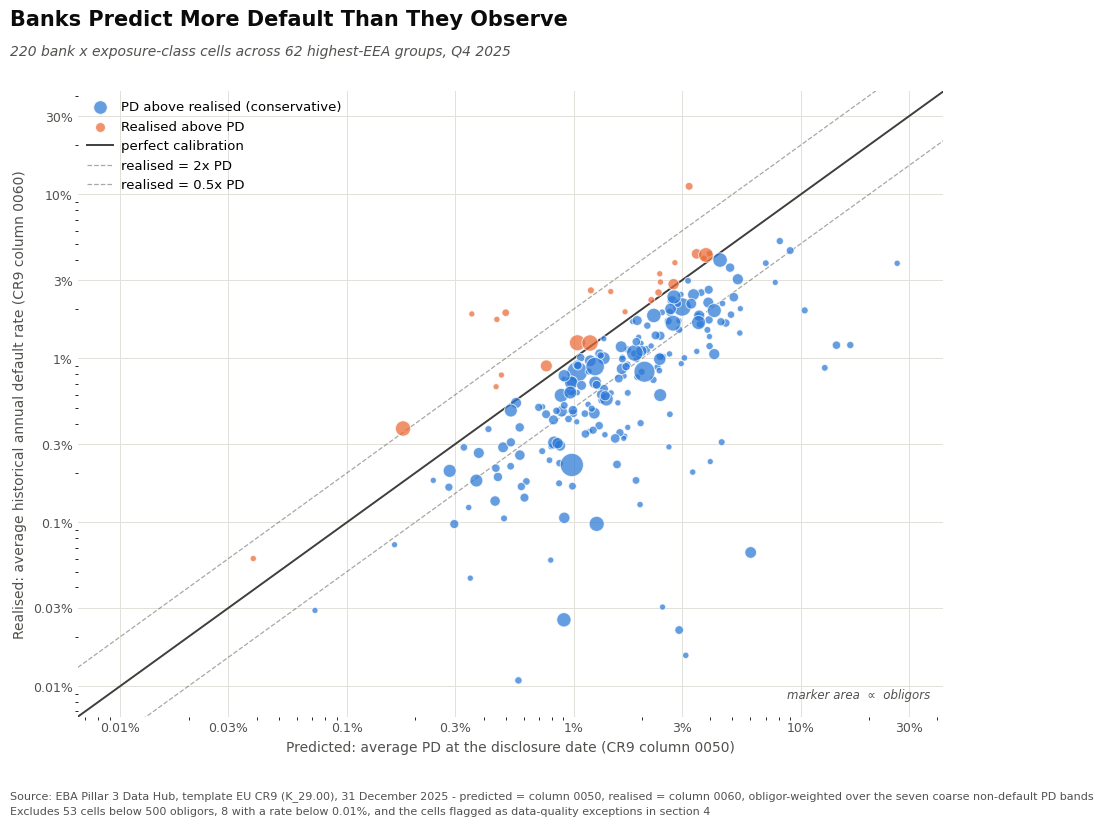

In [9]:
fig, ax = plt.subplots(figsize=(9.6, 8.2))

for factor, style, label in [(2.0, "--", "realised = 2x PD"),
                             (0.5, "--", "realised = 0.5x PD"),
                             (1.0, "-", "perfect calibration")]:
    ax.plot([lo, hi], [lo * factor, hi * factor], style, color=DIAGONAL,
            linewidth=1.4 if factor == 1 else 0.9,
            alpha=1.0 if factor == 1 else 0.45, label=label, zorder=1)

conservative = chart["calibration_ratio"] <= 1
for mask, colour, label in [(conservative, CONSERVATIVE, "PD above realised (conservative)"),
                            (~conservative, UNDER, "Realised above PD")]:
    part = chart[mask]
    ax.scatter(part["predicted_pd"], part["realised_hist_dr"],
               s=marker_size(part["obligors"]), c=colour, alpha=0.72,
               edgecolor="white", linewidth=0.7, label=label, zorder=3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
percent_axis(ax)
ax.set_xlabel("Predicted: average PD at the disclosure date (CR9 column 0050)",
              fontsize=10, color=MUTED)
ax.set_ylabel("Realised: average historical annual default rate (CR9 column 0060)",
              fontsize=10, color=MUTED)
ax.set_axisbelow(True)
ax.grid(color=GRID_LINE, linewidth=0.7)
ax.tick_params(length=0, colors=MUTED)
for side in ax.spines.values():
    side.set_visible(False)

ax.text(0.985, 0.03, "marker area  ∝  obligors", transform=ax.transAxes,
        ha="right", fontsize=8.5, color=MUTED, style="italic")
handles, labels = ax.get_legend_handles_labels()
order = [3, 4, 2, 0, 1]  # the two point classes first, then the guides
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc="upper left", frameon=False, fontsize=9.5, handletextpad=0.6,
          borderpad=0.2, scatterpoints=1, markerscale=0.8, labelspacing=0.5)

fig.tight_layout(rect=[0, 0.055, 1, 0.90])
fig.text(0.012, 0.962, "Banks Predict More Default Than They Observe",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.925,
         f"{len(chart)} bank x exposure-class cells across {chart['lei'].nunique()} "
         f"highest-EEA groups, Q4 2025",
         fontsize=10, style="italic", color=MUTED)
fig.text(0.012, 0.022, SOURCE_NOTE, fontsize=8, color=MUTED, va="center")
fig.text(0.012, 0.004,
         f"Excludes {dropped_small} cells below {MIN_OBLIGORS} obligors, {dropped_floor} with a "
         f"rate below {MIN_RATE_PCT}%, and the cells flagged as data-quality exceptions in section 4",
         fontsize=8, color=MUTED, va="center")
plt.show()

### 6.2 By exposure class

The same comparison split by exposure class, ordered by how many banks report each one. The
diagonal is unchanged, so panels are directly comparable.

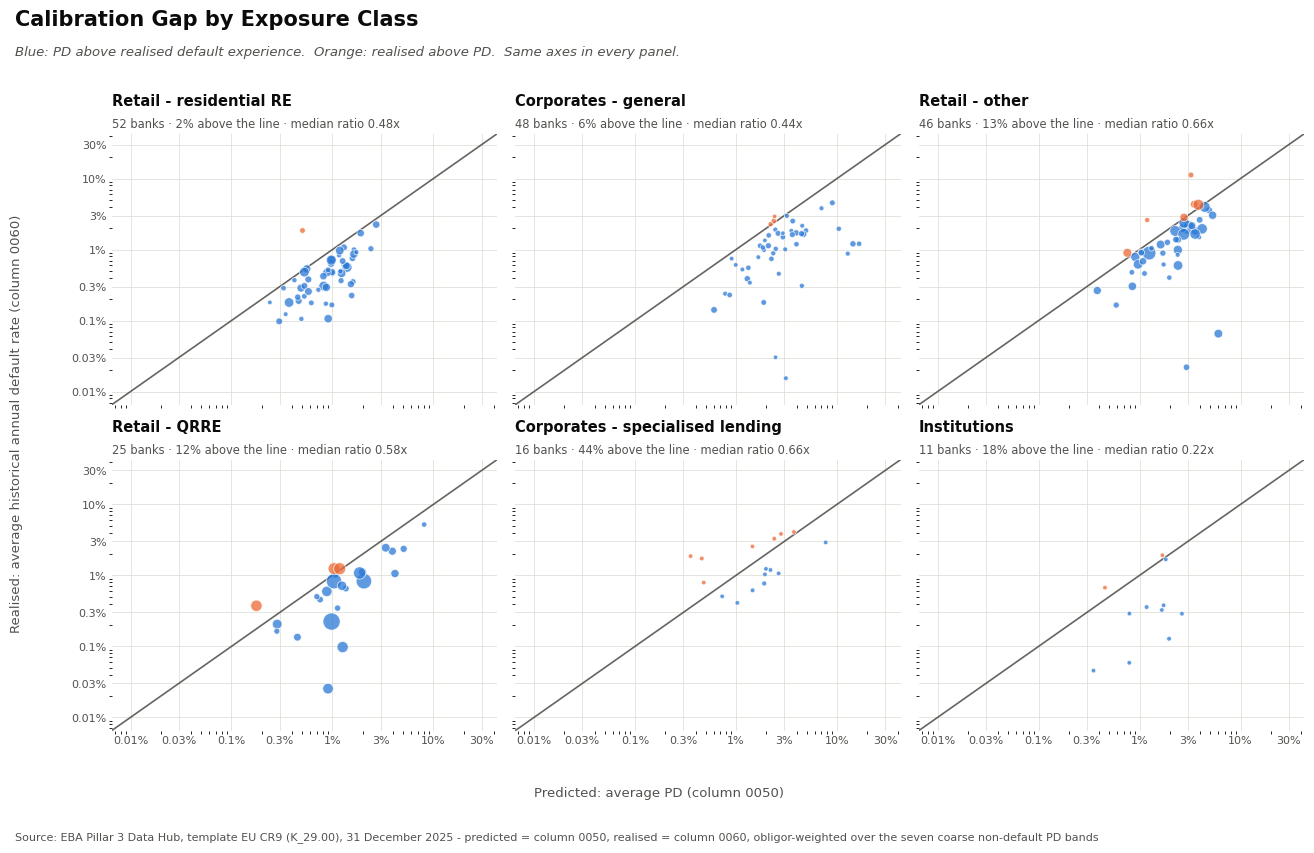

In [10]:
panel_classes = (chart.groupby("asset_class")["lei"].nunique()
                 .sort_values(ascending=False).head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.6), sharex=True, sharey=True)

for ax, asset_class in zip(axes.flat, panel_classes):
    part = chart[chart["asset_class"] == asset_class]
    ax.plot([lo, hi], [lo, hi], "-", color=DIAGONAL, linewidth=1.2, alpha=0.8, zorder=1)
    conservative = part["calibration_ratio"] <= 1
    ax.scatter(part.loc[conservative, "predicted_pd"],
               part.loc[conservative, "realised_hist_dr"],
               s=marker_size(part.loc[conservative, "obligors"]) * 0.55,
               c=CONSERVATIVE, alpha=0.75, edgecolor="white", linewidth=0.6, zorder=3)
    ax.scatter(part.loc[~conservative, "predicted_pd"],
               part.loc[~conservative, "realised_hist_dr"],
               s=marker_size(part.loc[~conservative, "obligors"]) * 0.55,
               c=UNDER, alpha=0.75, edgecolor="white", linewidth=0.6, zorder=3)

    share_under = 100 * (~conservative).mean()
    # Title above, one-line statistics immediately under it, both clear of the frame.
    ax.set_title(asset_class, fontsize=10.5, fontweight="bold", color=INK, loc="left", pad=20)
    ax.text(0.0, 1.012,
            f"{len(part)} banks · {share_under:.0f}% above the line · "
            f"median ratio {part['calibration_ratio'].median():.2f}x",
            transform=ax.transAxes, fontsize=8.3, color=MUTED, va="bottom")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    percent_axis(ax, fontsize=8)
    ax.set_axisbelow(True)
    ax.grid(color=GRID_LINE, linewidth=0.6)
    ax.tick_params(length=0, colors=MUTED)
    for side in ax.spines.values():
        side.set_visible(False)

for ax in axes.flat[len(panel_classes):]:
    ax.set_visible(False)

fig.supxlabel("Predicted: average PD (column 0050)", fontsize=9.5, color=MUTED, y=0.062)
fig.supylabel("Realised: average historical annual default rate (column 0060)",
              fontsize=9.5, color=MUTED, x=0.008)

fig.tight_layout(rect=[0.022, 0.075, 1, 0.90])
fig.text(0.012, 0.962, "Calibration Gap by Exposure Class",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.927,
         "Blue: PD above realised default experience.  Orange: realised above PD.  "
         "Same axes in every panel.",
         fontsize=9.5, style="italic", color=MUTED)
fig.text(0.012, 0.018, SOURCE_NOTE, fontsize=8, color=MUTED, va="center")
plt.show()

### 6.3 Bank by bank

The two most widely reported classes, one row per bank, sorted by the size of the gap. The bar
runs from the realised default rate to the predicted PD; blue means the PD sits above realised
experience, orange means it sits below.

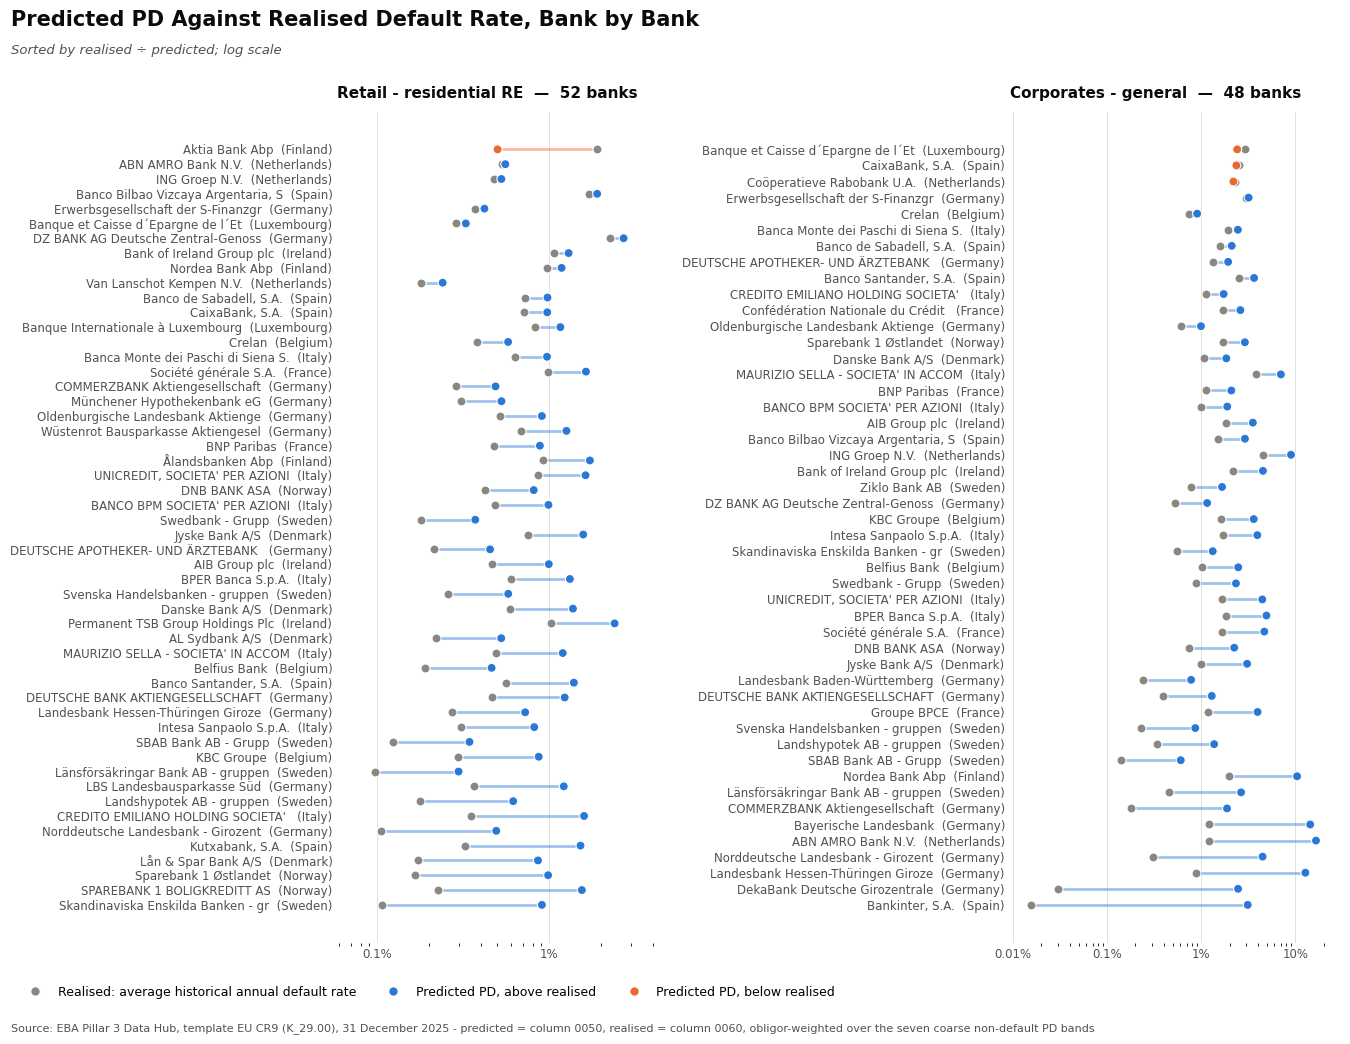

In [11]:
dumbbell_classes = (chart.groupby("asset_class")["lei"].nunique()
                    .sort_values(ascending=False).head(2).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13.6, 10.4))

for ax, asset_class in zip(axes, dumbbell_classes):
    part = (chart[chart["asset_class"] == asset_class]
            .sort_values("calibration_ratio", ascending=False)
            .reset_index(drop=True))
    y = range(len(part))

    for yi, row in part.iterrows():
        colour = UNDER if row["calibration_ratio"] > 1 else CONSERVATIVE
        ax.plot([row["realised_hist_dr"], row["predicted_pd"]], [yi, yi],
                color=colour, linewidth=2.0, alpha=0.45, solid_capstyle="round", zorder=2)

    ax.scatter(part["realised_hist_dr"], y, s=42, c=NEUTRAL, edgecolor="white",
               linewidth=0.8, label="Realised (column 0060)", zorder=3)
    ax.scatter(part["predicted_pd"], y, s=42,
               c=[UNDER if r > 1 else CONSERVATIVE for r in part["calibration_ratio"]],
               edgecolor="white", linewidth=0.8, label="Predicted PD (column 0050)", zorder=4)

    labels = [f"{b[:34]}  ({c})" for b, c in zip(part["bank"], part["country"])]
    ax.set_yticks(list(y), labels, fontsize=7.6)
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_xlim(0.6 * min(part["realised_hist_dr"].min(), part["predicted_pd"].min()),
                1.8 * max(part["realised_hist_dr"].max(), part["predicted_pd"].max()))
    # Each panel spans its own range, so let the log locator pick the decades and only
    # restyle the labels as percentages.
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_title(f"{asset_class}  —  {len(part)} banks", fontsize=11,
                 fontweight="bold", color=INK, loc="left", pad=10)
    ax.set_axisbelow(True)
    ax.grid(axis="x", color=GRID_LINE, linewidth=0.7)
    ax.tick_params(length=0, colors=MUTED, labelsize=8.5)
    for side in ax.spines.values():
        side.set_visible(False)

handles = [
    Line2D([], [], marker="o", linestyle="", markersize=7, markerfacecolor=NEUTRAL,
           markeredgecolor="white", label="Realised: average historical annual default rate"),
    Line2D([], [], marker="o", linestyle="", markersize=7, markerfacecolor=CONSERVATIVE,
           markeredgecolor="white", label="Predicted PD, above realised"),
    Line2D([], [], marker="o", linestyle="", markersize=7, markerfacecolor=UNDER,
           markeredgecolor="white", label="Predicted PD, below realised"),
]

fig.tight_layout(rect=[0, 0.055, 1, 0.925])
fig.text(0.012, 0.968, "Predicted PD Against Realised Default Rate, Bank by Bank",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.941, "Sorted by realised ÷ predicted; log scale", fontsize=9.5,
         style="italic", color=MUTED)
fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.012, 0.022),
           ncol=3, frameon=False, fontsize=9)
fig.text(0.012, 0.004, SOURCE_NOTE, fontsize=8, color=MUTED, va="center")
plt.show()

### 6.4 Along the fixed PD scale

Aggregating to the exposure class hides where in the PD scale the gap sits. This works at the
band level instead: for each of the seven coarse bands, the median predicted PD and the median
realised historical default rate across all reporting banks, against the band's own boundaries.

,coarse_order,band_label,cells,banks,obligors,median_predicted_pd,median_realised_hist_dr,pooled_1y_dr
0,1,0.00 to <0.15,299,62,99233866.0,0.080,0.060,0.055
1,2,0.15 to <0.25,263,64,25306285.0,0.195,0.130,0.129
2,3,0.25 to <0.50,289,64,33262806.0,0.360,0.225,0.208
3,4,0.50 to <0.75,258,61,15854955.0,0.610,0.370,0.422
4,5,0.75 to <2.5,298,67,35520878.0,1.380,0.740,0.951
5,6,2.5 to <10,281,65,21510601.0,4.614,2.641,3.187
6,7,10 to <100,249,64,8913278.0,22.840,10.480,14.212


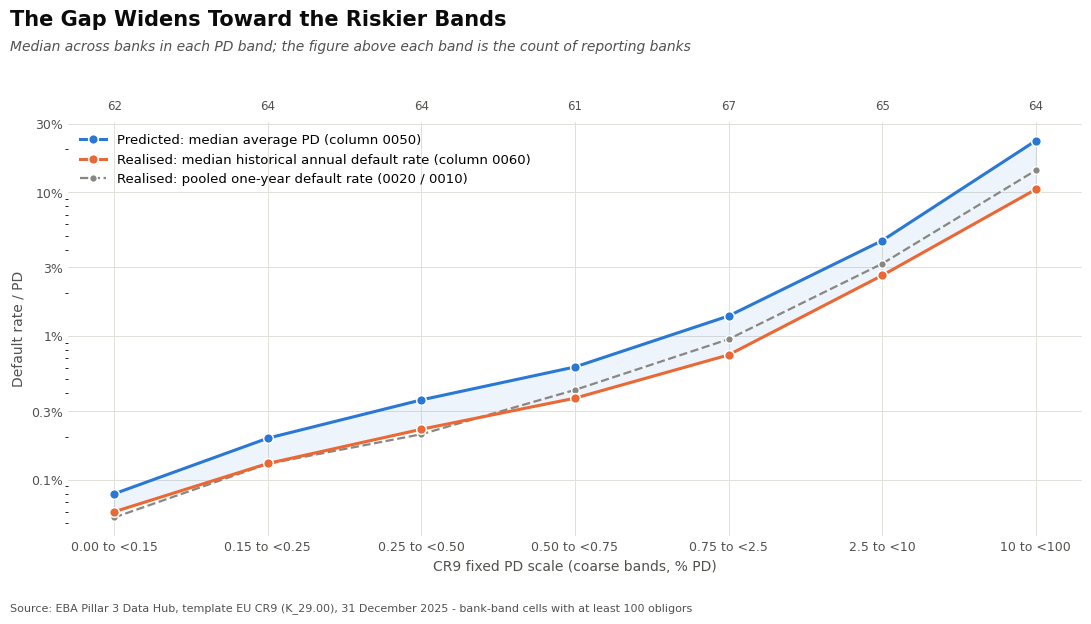

In [12]:
by_band = con.sql(f"""
WITH clean AS (
    SELECT b.*
    FROM irb_band AS b
    WHERE b.coarse_order BETWEEN 1 AND 7
      AND b.obligors >= 100
      AND coalesce(b.hist_dr, 0) <= 100
      AND coalesce(b.avg_pd, 0)  <= 100
)
SELECT
    coarse_order,
    band_label,
    count(*)                                          AS cells,
    count(DISTINCT lei)                               AS banks,
    sum(obligors)                                     AS obligors,
    median(avg_pd)                                    AS median_predicted_pd,
    median(hist_dr)                                   AS median_realised_hist_dr,
    100.0 * sum(defaulted) / nullif(sum(obligors), 0) AS pooled_1y_dr
FROM clean
GROUP BY coarse_order, band_label
ORDER BY coarse_order
""").df()
display(by_band.round(3))

fig, ax = plt.subplots(figsize=(11, 6.2))
x = range(len(by_band))

ax.plot(x, by_band["median_predicted_pd"], "-o", color=CONSERVATIVE, linewidth=2.2,
        markersize=7, markeredgecolor="white", markeredgewidth=1.1,
        label="Predicted: median average PD (column 0050)", zorder=3)
ax.plot(x, by_band["median_realised_hist_dr"], "-o", color=UNDER, linewidth=2.2,
        markersize=7, markeredgecolor="white", markeredgewidth=1.1,
        label="Realised: median historical annual default rate (column 0060)", zorder=3)
ax.plot(x, by_band["pooled_1y_dr"], "--o", color=NEUTRAL, linewidth=1.6,
        markersize=5.5, markeredgecolor="white", markeredgewidth=1.0,
        label="Realised: pooled one-year default rate (0020 / 0010)", zorder=2)

ax.fill_between(x, by_band["median_predicted_pd"], by_band["median_realised_hist_dr"],
                color=CONSERVATIVE, alpha=0.08, zorder=1)

ax.set_yscale("log")
ax.set_xticks(list(x), by_band["band_label"], fontsize=9.5)
ax.set_xlabel("CR9 fixed PD scale (coarse bands, % PD)", fontsize=10, color=MUTED)
ax.set_ylabel("Default rate / PD", fontsize=10, color=MUTED)
ax.yaxis.set_major_locator(FixedLocator([0.03, 0.1, 0.3, 1, 3, 10, 30]))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_axisbelow(True)
ax.grid(color=GRID_LINE, linewidth=0.7)
ax.tick_params(length=0, colors=MUTED, labelsize=9)
for side in ax.spines.values():
    side.set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)

# Reporting banks per band, along the top so the row cannot be mistaken for an axis.
for xi, row in by_band.iterrows():
    ax.text(xi, 1.022, f"{row['banks']:.0f}", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=8.5, color=MUTED)

fig.tight_layout(rect=[0, 0.05, 1, 0.865])
fig.text(0.012, 0.958, "The Gap Widens Toward the Riskier Bands",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.918,
         "Median across banks in each PD band; the figure above each band is the count of "
         "reporting banks",
         fontsize=10, style="italic", color=MUTED)
fig.text(0.012, 0.018,
         "Source: EBA Pillar 3 Data Hub, template EU CR9 (K_29.00), 31 December 2025 - "
         "bank-band cells with at least 100 obligors",
         fontsize=8, color=MUTED, va="center")
plt.show()

### 6.5 Estimated LGD: prescribed against own estimates

The clearest signal in the LGD data is not its level but its **shape**. Under the foundation
approach LGD is set by the CRR, so FIRB cells should pile up on the supervisory values; under the
advanced approach the bank estimates it, so AIRB cells should spread. Both panels are band-level
CR6 cells, one per bank × member × PD band, weighted by nothing — this is the distribution of
disclosed values, so a spike means many cells report the same number.

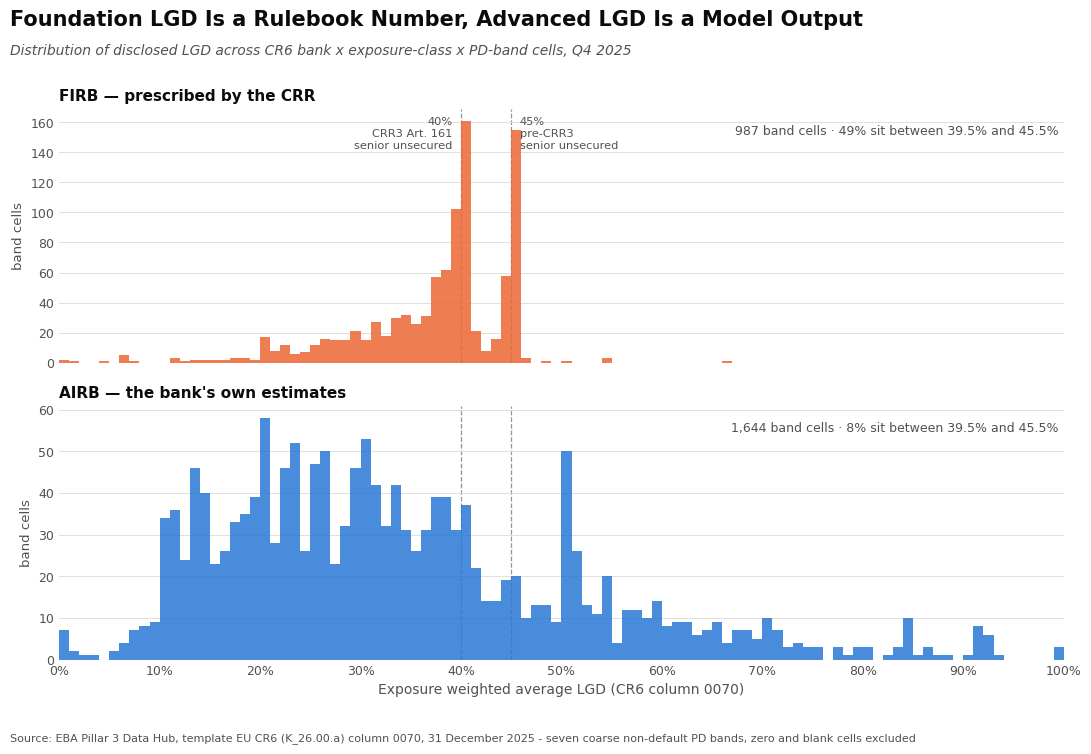

In [13]:
lgd_cells = con.sql("""
SELECT
    lgd,
    CASE
        WHEN lower(member) LIKE '%without own estimates%' THEN 'FIRB'
        WHEN lower(member) LIKE '%with own estimates%'    THEN 'AIRB'
        ELSE 'n/a'
    END AS irb_variant
FROM irb_band
WHERE coarse_order BETWEEN 1 AND 7 AND lgd > 0 AND lgd <= 100
""").df()

PRESCRIBED = [(45.0, "45%\npre-CRR3\nsenior unsecured"),
              (40.0, "40%\nCRR3 Art. 161\nsenior unsecured")]
fig, axes = plt.subplots(2, 1, figsize=(11, 7.6), sharex=True)

for ax, variant, colour, note in [
    (axes[0], "FIRB", UNDER, "prescribed by the CRR"),
    (axes[1], "AIRB", CONSERVATIVE, "the bank's own estimates"),
]:
    part = lgd_cells.loc[lgd_cells["irb_variant"] == variant, "lgd"]
    ax.hist(part, bins=range(0, 101), color=colour, alpha=0.85, edgecolor="none")
    for value, label in PRESCRIBED:
        ax.axvline(value, color=DIAGONAL, linewidth=0.9, linestyle="--", alpha=0.55, zorder=0)
    within = 100 * part.between(39.5, 45.5).mean()
    ax.set_title(f"{variant} — {note}", fontsize=11, fontweight="bold", color=INK,
                 loc="left", pad=6)
    ax.text(0.995, 0.90, f"{len(part):,} band cells · {within:.0f}% sit between 39.5% and 45.5%",
            transform=ax.transAxes, ha="right", fontsize=9, color=MUTED)
    ax.set_ylabel("band cells", fontsize=9.5, color=MUTED)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=GRID_LINE, linewidth=0.7)
    ax.tick_params(length=0, colors=MUTED, labelsize=9)
    for side in ax.spines.values():
        side.set_visible(False)

for value, label in PRESCRIBED:
    axes[0].annotate(label, xy=(value, axes[0].get_ylim()[1] * 0.97),
                     xytext=(6 if value == 45 else -6, 0), textcoords="offset points",
                     ha="left" if value == 45 else "right", va="top",
                     fontsize=8.2, color=MUTED, linespacing=1.25)

axes[1].set_xlim(0, 100)
axes[1].set_xticks(range(0, 101, 10), [f"{v}%" for v in range(0, 101, 10)], fontsize=9)
axes[1].set_xlabel("Exposure weighted average LGD (CR6 column 0070)", fontsize=10, color=MUTED)

fig.tight_layout(rect=[0, 0.055, 1, 0.895])
fig.text(0.012, 0.958, "Foundation LGD Is a Rulebook Number, Advanced LGD Is a Model Output",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.920,
         "Distribution of disclosed LGD across CR6 bank x exposure-class x PD-band cells, Q4 2025",
         fontsize=10, style="italic", color=MUTED)
fig.text(0.012, 0.020,
         "Source: EBA Pillar 3 Data Hub, template EU CR6 (K_26.00.a) column 0070, "
         "31 December 2025 - seven coarse non-default PD bands, zero and blank cells excluded",
         fontsize=8, color=MUTED, va="center")
plt.show()

The two spikes are the supervisory values for senior unsecured corporate exposures under the
foundation approach: 45% under the original CRR, reduced to **40% by CRR3's amendment of Article
161(1)**. Roughly half of all FIRB band cells sit in the 39.5–45.5% window against well under a
tenth of AIRB cells, and the FIRB mass between the spikes and below them is collateralised
exposure, where the prescribed LGD is reduced by recognised collateral rather than estimated.

It is also an independent check on the AIRB/FIRB classification itself, which is read from the
CR6 member text alone: the LGD distributions that fall out of that split behave exactly as the
regulation requires, which no arrangement of the text could produce by accident.

### 6.6 LGD by exposure class

Portfolio LGD per bank and exposure class, exposure-weighted. Each dot is one bank; the bar is the
interquartile range and the notch the median. Where a class carries both variants they are drawn
side by side, so the prescribed-versus-estimated gap is readable per class.

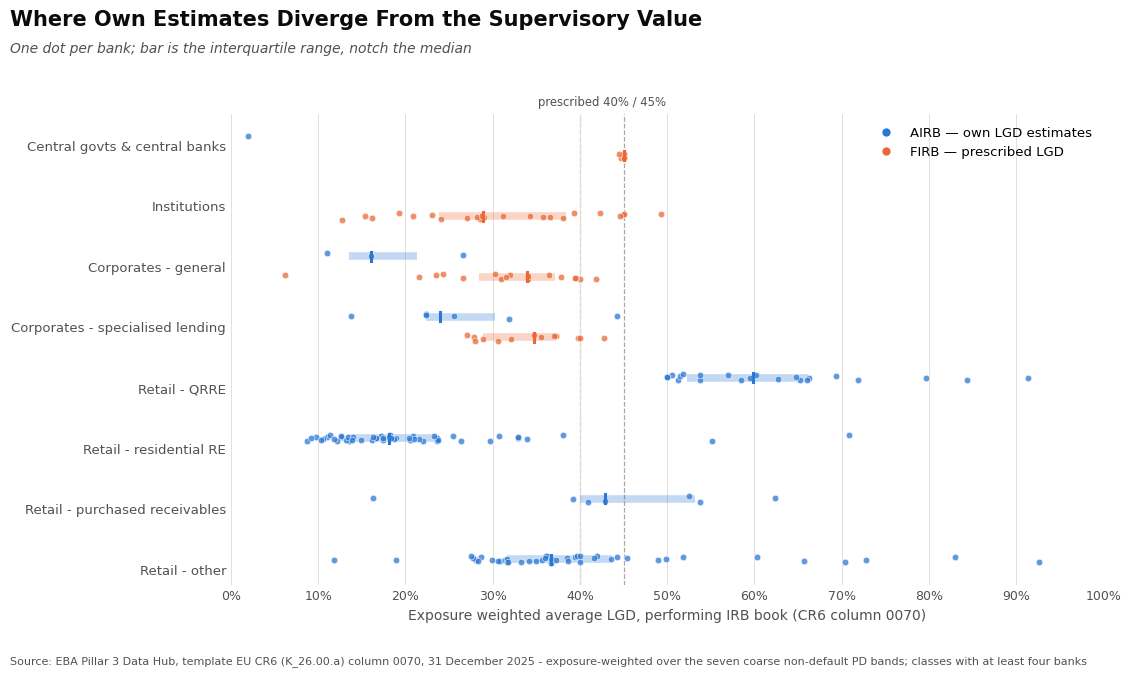

In [14]:
lgd_class = con.sql("""
SELECT bank, asset_class, class_order, irb_variant, lgd, ead
FROM cr9_backtest
WHERE dq_exception IS NULL AND lgd > 0 AND lgd <= 100
  AND irb_variant IN ('AIRB', 'FIRB')
""").df()

order = (lgd_class.groupby(["asset_class", "class_order"]).size()
         .reset_index().sort_values("class_order")["asset_class"].tolist())
order = [c for c in order if (lgd_class["asset_class"] == c).sum() >= 4]

fig, ax = plt.subplots(figsize=(11.4, 6.8))
rng = __import__("numpy").random.default_rng(7)

for i, asset_class in enumerate(order):
    for offset, variant, colour in [(-0.17, "AIRB", CONSERVATIVE), (0.17, "FIRB", UNDER)]:
        part = lgd_class[(lgd_class["asset_class"] == asset_class)
                         & (lgd_class["irb_variant"] == variant)]["lgd"]
        if part.empty:
            continue
        y = i + offset
        if len(part) >= 3:
            ax.plot([part.quantile(0.25), part.quantile(0.75)], [y, y],
                    color=colour, linewidth=5.5, alpha=0.28, solid_capstyle="butt", zorder=1)
            ax.plot([part.median()] * 2, [y - 0.075, y + 0.075],
                    color=colour, linewidth=2.2, zorder=4)
        ax.scatter(part, y + rng.uniform(-0.055, 0.055, len(part)), s=22, c=colour,
                   alpha=0.75, edgecolor="white", linewidth=0.5, zorder=3)

for value in (40.0, 45.0):
    ax.axvline(value, color=DIAGONAL, linewidth=0.9, linestyle="--", alpha=0.45, zorder=0)
# Anchored to the top of the frame so it cannot collide with the axis label below.
ax.text(42.5, 1.012, "prescribed 40% / 45%", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=8.4, color=MUTED)

ax.set_yticks(range(len(order)), order, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10), [f"{v}%" for v in range(0, 101, 10)], fontsize=9)
ax.set_xlabel("Exposure weighted average LGD, performing IRB book (CR6 column 0070)",
              fontsize=10, color=MUTED)
ax.set_axisbelow(True)
ax.grid(axis="x", color=GRID_LINE, linewidth=0.7)
ax.tick_params(length=0, colors=MUTED)
for side in ax.spines.values():
    side.set_visible(False)

handles = [
    Line2D([], [], marker="o", linestyle="", markersize=7, markerfacecolor=CONSERVATIVE,
           markeredgecolor="white", label="AIRB — own LGD estimates"),
    Line2D([], [], marker="o", linestyle="", markersize=7, markerfacecolor=UNDER,
           markeredgecolor="white", label="FIRB — prescribed LGD"),
]
ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9.5)

fig.tight_layout(rect=[0, 0.055, 1, 0.875])
fig.text(0.012, 0.955, "Where Own Estimates Diverge From the Supervisory Value",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.915,
         "One dot per bank; bar is the interquartile range, notch the median",
         fontsize=10, style="italic", color=MUTED)
fig.text(0.012, 0.020,
         "Source: EBA Pillar 3 Data Hub, template EU CR6 (K_26.00.a) column 0070, "
         "31 December 2025 - exposure-weighted over the seven coarse non-default PD bands; "
         "classes with at least four banks",
         fontsize=8, color=MUTED, va="center")
plt.show()

### 6.7 Mortgage portfolios: PD against LGD

Residential mortgages are the one class where nearly every IRB bank in the sample reports both
parameters, they are all AIRB (retail IRB requires own LGD estimates), and the portfolios are
economically comparable across countries. That makes it the natural place to put the two estimated
parameters on one plane and look at individual banks.

Both axes are **exposure-weighted CR6 figures** — PD from column `0050`, LGD from column `0070` —
so their product is a coherent expected loss rate and the curved guides are iso-expected-loss
lines. A bank on a lower curve is not necessarily safer: it may hold better-collateralised
exposure, a different national mortgage market, or a different view of downturn conditions.

The class is the CRR retail exposure class *secured by residential immovable property*
(`Retail exposures - Secured by residential real estate`).

#### Validating the parameters before plotting them

A disclosed PD or LGD cannot be taken at face value: the percentage-scale convention is
inconsistent across filers (§4), and a parameter can be missing for part of the book, in which
case an exposure-weighted average describes only the part that was reported.

CR6 makes both failures detectable, because it also discloses the **expected loss amount**.
Regulatory EL is defined as `EAD × PD × LGD` (Article 158 CRR), so for every bank:

```text
el_check_ratio = (EL ÷ EAD) ÷ (PD × LGD)      ->   should be ≈ 1
```

This is an independent corroboration from the bank's own filing, using no assumption of ours. Two
screens are applied before a bank enters the chart:

1. `el_check_ratio` within `[0.5, 2.0]` — parameters agree with the disclosed EL
2. PD and LGD each reported for at least 90% of the class EAD — the average describes the book

A third and stronger check sits behind both. **CR6 row `0180` is the bank's own subtotal for the
exposure class**, carrying its own exposure-weighted PD and LGD. Rebuilding that row from the PD
bands tests the weighting, the band selection and the scale factor in one go — against the
institution's own arithmetic rather than any rule of ours. It reproduces it: across all bank-class
cells the median absolute LGD gap is **0.0007 percentage points**, and EAD matches to within 1%
in all but one cell.

The one expected difference: the subtotal spans all bands including `100 (Default)`, whereas every
analytical figure in this notebook stops before it. So the disclosed subtotal sits slightly
*above* the performing-book average, by the weight of the defaulted band. Where a bank's bands
and its own subtotal disagree, the bands are used — they are the level every figure here is
built from.

In [15]:
# The expected-loss corroboration across mortgage books: (EL / EAD) divided by (PD x LGD),
# which reads about 1 wherever both parameters are on the right scale and cover the whole book.
display(con.sql("""
SELECT count(*) AS banks,
       quantile_cont(el_check_ratio, 0.05) AS p05,
       quantile_cont(el_check_ratio, 0.25) AS p25,
       median(el_check_ratio)              AS median,
       quantile_cont(el_check_ratio, 0.75) AS p75,
       quantile_cont(el_check_ratio, 0.95) AS p95
FROM cr9_backtest
WHERE asset_class = 'Retail - residential RE' AND el_check_ratio IS NOT NULL
""").df().round(3))

,banks,p05,p25,median,p75,p95
0,60,0.912,0.999,1.048,1.149,1.277


The check clears almost the whole sample — the median bank's disclosed EL sits within a few
percent of its own `PD × LGD` — and isolates two failures.

One bank reports **identical values in columns `0050` and `0070` in every single row**, so one
column has been filled with the other; its disclosed EL implies a `PD × LGD` product roughly
**370 times** larger than the pair it reports, and its conversion factor column is scaled by about
10⁶. Its LGD is not usable at all. The other leaves PD blank in its two largest bands, so an
exposure-weighted PD over what remains reads a full half point above the subtotal the bank itself
discloses; the coverage screen catches this, where a scale check alone would not have. Both are
excluded.

Everything else stands, **including the high LGDs**. The Spanish, Irish and German cells above 30%
are corroborated by those banks' own expected-loss disclosures to within a few percent — they are
what was filed, not an artefact of our rescaling.

58 banks pass the EL and coverage screens (2 failed them); 55 inside the plotted range


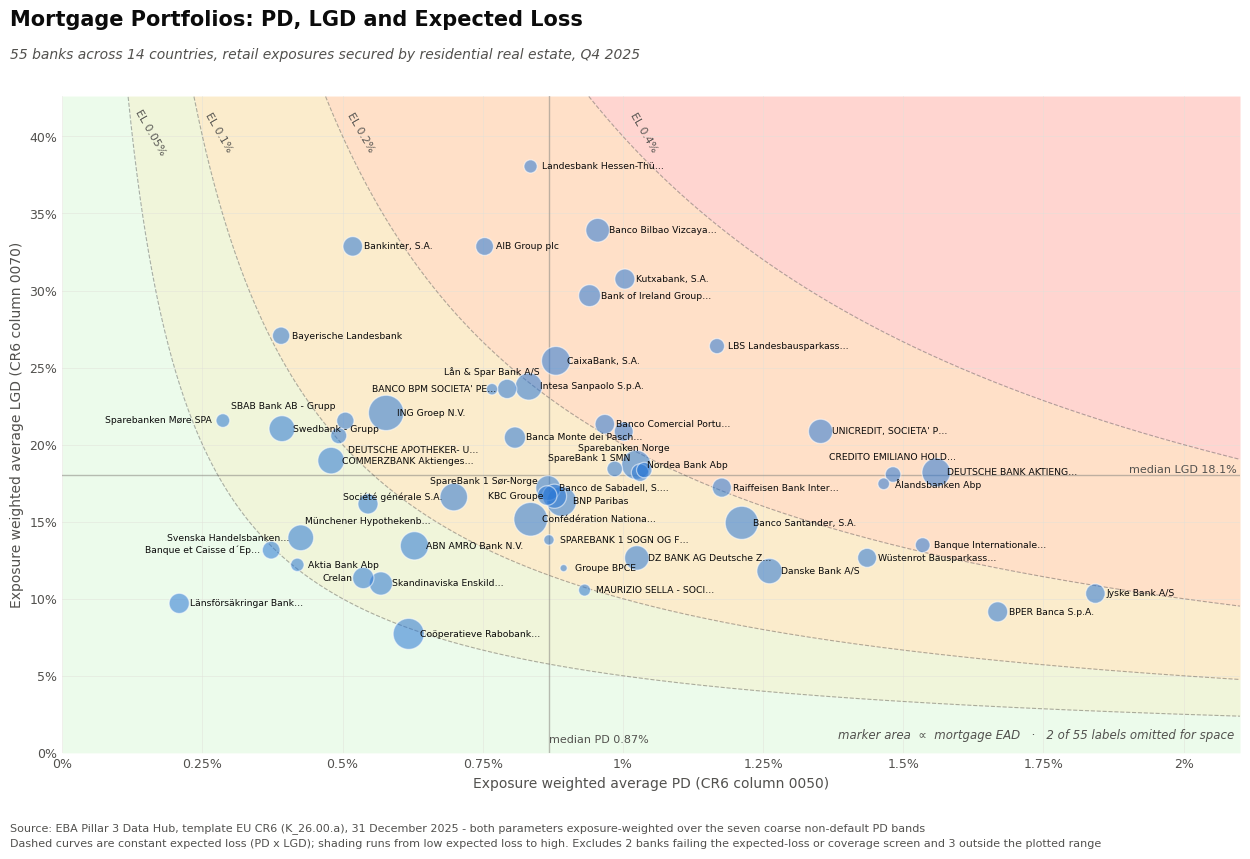

,bank,country,cr6_pd,lgd,el_rate,ead_bn,realised_hist_dr,el_check_ratio
0,ING Groep N.V.,Netherlands,0.578,22.058,0.127,360.266,0.480,0.937
1,Confédération Nationale du Crédit Mutuel,France,0.835,15.156,0.127,295.159,NaN,1.152
2,"Banco Santander, S.A.",Spain,1.212,14.926,0.181,276.168,0.563,0.951
3,Coöperatieve Rabobank U.A.,Netherlands,0.618,7.720,0.048,209.205,NaN,1.402
4,BNP Paribas,France,0.891,16.311,0.145,174.230,0.475,1.219
5,Nordea Bank Abp,Finland,1.024,18.688,0.191,159.878,0.967,1.029
6,"CaixaBank, S.A.",Spain,0.880,25.436,0.224,152.828,0.710,1.045
7,DEUTSCHE BANK AKTIENGESELLSCHAFT,Germany,1.559,18.198,0.284,145.062,0.463,1.150
8,ABN AMRO Bank N.V.,Netherlands,0.628,13.435,0.084,141.415,0.534,1.077
9,Société générale S.A.,France,0.698,16.598,0.116,126.722,0.990,1.079


In [16]:
# This chart reads only CR6, so it is gated on CR6 plausibility rather than on the CR9 DQ
# flags: excluding a bank because its CR9 columns are incomplete would drop perfectly good
# parameter disclosures. The EL and coverage screens above do the work instead.
mortgage_all = con.sql("""
SELECT bank, country, lei, cr6_pd, lgd, ead, obligors,
       predicted_pd, realised_hist_dr, cr6_pd * lgd / 100.0 AS el_rate,
       el_check_ratio, pd_ead_coverage, lgd_ead_coverage, source_link
FROM cr9_backtest
WHERE asset_class = 'Retail - residential RE'
  AND cr6_pd > 0 AND cr6_pd <= 100
  AND lgd    > 0 AND lgd    <= 100
  AND (el_check_ratio IS NULL OR el_check_ratio BETWEEN 0.5 AND 2.0)
  AND coalesce(pd_ead_coverage,  1) >= 0.9
  AND coalesce(lgd_ead_coverage, 1) >= 0.9
ORDER BY ead DESC
""").df()
dq_excluded = con.sql("""
SELECT count(*) AS n FROM cr9_backtest
WHERE asset_class = 'Retail - residential RE' AND cr6_pd > 0 AND lgd > 0
  AND (el_check_ratio NOT BETWEEN 0.5 AND 2.0
       OR coalesce(pd_ead_coverage, 1) < 0.9 OR coalesce(lgd_ead_coverage, 1) < 0.9)
""").df()["n"].iloc[0]

# The plotted window. A few disclosures reconcile to their own expected loss but sit far
# enough from the rest that drawing them squeezes the population the chart is about into a
# corner. A stated range keeps the frame readable and, unlike a fixed list of banks, still
# means the same thing when the notebook is re-run against a later reference date.
LGD_PLOT_MAX, PD_PLOT_MAX = 50.0, 2.0
mortgage = mortgage_all[(mortgage_all["lgd"] <= LGD_PLOT_MAX)
                        & (mortgage_all["cr6_pd"] <= PD_PLOT_MAX)].reset_index(drop=True)
off_scale = len(mortgage_all) - len(mortgage)

print(f"{len(mortgage_all)} banks pass the EL and coverage screens "
      f"({dq_excluded} failed them); {len(mortgage)} inside the plotted range")

ISO_EL = [0.05, 0.10, 0.20, 0.40]      # expected loss as a % of EAD

# One fill per region between successive curves, running from low expected loss to high.
# The steps are pale so the markers stay dominant, and their lightness falls monotonically
# across the ramp, so the ordering survives greyscale and colour-vision-deficient rendering
# instead of resting on the green-to-red hue shift alone.
EL_BANDS = ["#ecfbeb", "#f0f5da", "#fbeccc", "#ffe0c8", "#ffd5d0"]

X_MAX = mortgage["cr6_pd"].max() * 1.14
Y_MAX = mortgage["lgd"].max() * 1.12

fig, ax = plt.subplots(figsize=(12.6, 8.8))
np = __import__("numpy")

# A fine grid starting near zero: the curves rise steeply at low PD, and the fills have to
# reach the left edge of the frame.
pd_grid = np.linspace(1e-4, X_MAX, 1200)

band_edges = [0.0] + ISO_EL + [float("inf")]
for lower_el, upper_el, colour in zip(band_edges, band_edges[1:], EL_BANDS):
    lower = (np.zeros_like(pd_grid) if lower_el == 0.0
             else np.clip(100.0 * lower_el / pd_grid, 0, Y_MAX))
    upper = (np.full_like(pd_grid, Y_MAX) if upper_el == float("inf")
             else np.clip(100.0 * upper_el / pd_grid, 0, Y_MAX))
    ax.fill_between(pd_grid, lower, upper, color=colour, linewidth=0, zorder=0)

# Iso-expected-loss curves: LGD = 100 * EL / PD.
for el in ISO_EL:
    lgd_curve = 100.0 * el / pd_grid
    visible = lgd_curve <= Y_MAX
    ax.plot(pd_grid[visible], lgd_curve[visible], color=DIAGONAL, linewidth=0.8,
            linestyle="--", alpha=0.4, zorder=1)
    x_label = 100.0 * el / (Y_MAX * 0.93)
    if x_label < X_MAX * 0.95:
        ax.text(x_label, Y_MAX * 0.945, f"EL {el:g}%", fontsize=7.8, color=MUTED,
                ha="left", va="center", rotation=-60, alpha=0.95)

med_pd, med_lgd = mortgage["cr6_pd"].median(), mortgage["lgd"].median()
ax.axvline(med_pd, color=NEUTRAL, linewidth=1.0, alpha=0.55, zorder=0.6)
ax.axhline(med_lgd, color=NEUTRAL, linewidth=1.0, alpha=0.55, zorder=0.6)
# Both labels sit inside the frame; anchoring them outside pushes the axis titles off-canvas.
ax.text(med_pd, 0.012, f"median PD {med_pd:.2f}%", transform=ax.get_xaxis_transform(),
        ha="left", va="bottom", fontsize=8, color=MUTED, zorder=6)
ax.text(0.997, med_lgd, f"median LGD {med_lgd:.1f}%", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=8, color=MUTED, zorder=6)

sizes = 26 + 620 * (mortgage["ead"] / mortgage["ead"].max()) ** 0.5
ax.scatter(mortgage["cr6_pd"], mortgage["lgd"], s=sizes, c=CONSERVATIVE, alpha=0.55,
           edgecolor="white", linewidth=0.9, zorder=3)


def place_labels(texts, xs, ys, fontsize=6.7):
    """Label every point, trying candidate offsets until one lands clear of the rest.

    Points are labelled largest-exposure first, so if the plane runs out of room it is the
    smallest portfolios that lose their label — and the count is reported, never hidden.
    """
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    taken, skipped = [], 0
    candidates = [
        (8, 0, "left", "center"), (-8, 0, "right", "center"),
        (0, 9, "center", "bottom"), (0, -9, "center", "top"),
        (7, 7, "left", "bottom"), (-7, 7, "right", "bottom"),
        (7, -7, "left", "top"), (-7, -7, "right", "top"),
        (16, 0, "left", "center"), (-16, 0, "right", "center"),
        (0, 17, "center", "bottom"), (0, -17, "center", "top"),
    ]
    frame = ax.get_window_extent(renderer=renderer)
    for text, x, y in zip(texts, xs, ys):
        for dx, dy, ha, va in candidates:
            note = ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                               ha=ha, va=va, fontsize=fontsize, color=INK, zorder=5)
            box = note.get_window_extent(renderer=renderer).expanded(1.04, 1.12)
            if frame.contains(box.x0, box.y0) and frame.contains(box.x1, box.y1) \
                    and not any(box.overlaps(other) for other in taken):
                taken.append(box)
                break
            note.remove()
        else:
            skipped += 1
    return skipped


labels = [b if len(b) <= 22 else b[:21].rstrip() + "…" for b in mortgage["bank"]]
ax.set_xlim(0, X_MAX)
ax.set_ylim(0, Y_MAX)
unlabelled = place_labels(labels, mortgage["cr6_pd"], mortgage["lgd"])

ax.set_xlabel("Exposure weighted average PD (CR6 column 0050)", fontsize=10, color=MUTED)
ax.set_ylabel("Exposure weighted average LGD (CR6 column 0070)", fontsize=10, color=MUTED)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set_axisbelow(True)
ax.grid(color=GRID_LINE, linewidth=0.55, alpha=0.6)
ax.tick_params(length=0, colors=MUTED, labelsize=9)
for side in ax.spines.values():
    side.set_visible(False)
note = "marker area  ∝  mortgage EAD"
if unlabelled:
    note += f"   ·   {unlabelled} of {len(mortgage)} labels omitted for space"
ax.text(0.995, 0.022, note, transform=ax.transAxes,
        ha="right", fontsize=8.5, color=MUTED, style="italic")

# Footer lines are kept short on purpose: the inline backend saves with bbox_inches="tight",
# so a caption wider than the canvas silently stretches the exported figure.
fig.tight_layout(rect=[0, 0.072, 1, 0.895])
fig.text(0.012, 0.958, "Mortgage Portfolios: PD, LGD and Expected Loss",
         fontsize=15, fontweight="bold", color=INK)
fig.text(0.012, 0.921,
         f"{len(mortgage)} banks across {mortgage['country'].nunique()} countries, "
         f"retail exposures secured by residential real estate, Q4 2025",
         fontsize=10, style="italic", color=MUTED)
fig.text(0.012, 0.046,
         "Source: EBA Pillar 3 Data Hub, template EU CR6 (K_26.00.a), 31 December 2025 - "
         "both parameters exposure-weighted over the seven coarse non-default PD bands",
         fontsize=8, color=MUTED, va="center")
fig.text(0.012, 0.028,
         "Dashed curves are constant expected loss (PD x LGD); shading runs from low "
         "expected loss to high. "
         f"Excludes {dq_excluded} banks failing the expected-loss or coverage screen and "
         f"{off_scale} outside the plotted range",
         fontsize=8, color=MUTED, va="center")
plt.show()

display(mortgage.assign(ead_bn=lambda d: d["ead"] / 1e9)
        [["bank", "country", "cr6_pd", "lgd", "el_rate", "ead_bn", "realised_hist_dr",
          "el_check_ratio"]]
        .head(15).round(3))

**Reading it.** The vertical spread is much wider than the horizontal one: mortgage PD sits in a
narrow band for almost everyone, while LGD ranges from single digits to over 50%. Loss severity,
not default frequency, is what separates these portfolios — which is what you would expect when
the underlying risk is the same product and the difference is collateral, loan-to-value practice
and national foreclosure regimes.

The country pattern is in LGD, not PD. Median mortgage LGD runs from roughly 11–12% in the
Netherlands, Denmark and Sweden, through 17–20% in Finland, Norway, Germany and Italy, to 28% in
Spain and 30% in Ireland. The three highest individual values are German public-sector banks, but
Germany's median sits mid-pack — that is a tail, not a national position. The largest markers
cluster near the median on both axes: the biggest mortgage books are not the ones taking outlying
parameter positions.

The high-LGD cluster is the part worth stress-testing, because a mortgage LGD above 30% looks
wrong at first sight. It survives: Helaba at 38.1%, BBVA at 33.9%, Bankinter and AIB at 32.9% and
Kutxabank at 30.7% each disclose an expected loss amount that reproduces their own `PD × LGD` to
within a few percent. Spanish and Irish severities reflect post-crisis recovery experience and
long foreclosure timelines. High, but as filed and internally consistent — not a rescaling
artefact.

## 7. Detail by bank and exposure class

Every clean cell, with both predicted measures, all three realised measures, the IRB variant, a
flag for the repaired open key and a link to the bank's own filing in the Hub.

In [17]:
detail = con.sql("""
SELECT
    country, bank, lei, asset_class, irb_variant,
    obligors, defaulted, ead,
    predicted_pd, predicted_ew_pd, cr6_pd,
    realised_hist_dr, observed_avg_dr, realised_1y_dr, calibration_ratio,
    lgd, ccf,
    expected_loss, provisions, expected_loss_pct_ead, provision_cover_of_el,
    band_cells, member_repaired, source_link
FROM cr9_backtest
WHERE dq_exception IS NULL
ORDER BY country, bank, class_order
""").df()
print(f"{len(detail)} clean bank-class cells across {detail['lei'].nunique()} banks")

# CR6 coverage is not universal. A blank LGD or EAD below is a filing fact, not a failed join:
# a handful of banks file only part of CR6.a, and one files a single column of it.
cr6_coverage = con.sql("""
SELECT count(DISTINCT lei) FILTER (WHERE cols = 6) AS all_six_columns,
       count(DISTINCT lei) FILTER (WHERE cols BETWEEN 2 AND 5) AS partial,
       count(DISTINCT lei) FILTER (WHERE cols = 1) AS single_column
FROM (SELECT lei, count(DISTINCT column_code) AS cols
      FROM irb_facts WHERE template = 'CR6' GROUP BY lei)
""").df()
print("CR6 column coverage per bank:",
      cr6_coverage.to_dict("records")[0])
display(detail.sort_values("lgd", na_position="last").head(40).round(3))

281 clean bank-class cells across 67 banks
CR6 column coverage per bank: {'all_six_columns': 71, 'partial': 4, 'single_column': 2}


,country,bank,lei,asset_class,irb_variant,obligors,defaulted,ead,predicted_pd,predicted_ew_pd,cr6_pd,realised_hist_dr,observed_avg_dr,realised_1y_dr,calibration_ratio,lgd,ccf,expected_loss,provisions,expected_loss_pct_ead,provision_cover_of_el,band_cells,member_repaired,source_link
41,France,BNP Paribas,R0MUWSFPU8MPRO8K5P83,Central govts & central banks,AIRB,689.0,0.0,4.028671e+11,0.571,0.607,0.068,0.000,0.000,0.000,0.000,1.934,41.981,2.449328e+07,NaN,0.006,NaN,7,False,https://errp.eba.europa.eu/public-documents/CO...
58,France,Société générale S.A.,O2RNE8IBXP4R0TD8PU41,Central govts & central banks,AIRB + FIRB,860.0,0.0,2.535610e+11,0.592,0.492,0.107,0.000,0.000,0.000,0.000,2.781,39.056,5.487379e+07,-1.744224e+07,0.022,-0.318,14,False,https://errp.eba.europa.eu/public-documents/CO...
262,Sweden,SBAB Bank AB - Grupp,H0YX5LBGKDVOWCXBZ594,Corporates - general,FIRB,203675.0,204.0,3.558874e+10,0.606,0.628,0.405,0.141,0.100,0.100,0.233,6.225,27.405,9.525717e+06,-5.392591e+06,0.027,-0.566,6,True,https://errp.eba.europa.eu/public-documents/CO...
43,France,BNP Paribas,R0MUWSFPU8MPRO8K5P83,Public-sector entities,AIRB,307.0,3.0,6.209342e+09,1.355,1.544,0.332,0.404,0.977,0.977,0.298,8.004,25.205,1.471675e+06,NaN,0.024,NaN,7,False,https://errp.eba.europa.eu/public-documents/CO...
258,Sweden,Landshypotek AB - gruppen,5493004WUGGU2BQI7F14,Retail - residential RE,AIRB,52031.0,79.0,6.469552e+09,0.618,1.935,1.874,0.177,0.444,0.152,0.287,8.732,51.962,4.173592e+06,3.305689e+05,0.065,0.079,7,False,https://errp.eba.europa.eu/public-documents/CO...
161,Italy,BPER Banca S.p.A.,N747OI7JINV7RUUH6190,Retail - residential RE,AIRB,296384.0,1070.0,3.082895e+10,1.320,1.334,1.668,0.601,0.361,0.361,0.456,9.152,57.749,6.549455e+07,-1.220492e+08,0.212,-1.864,7,False,https://errp.eba.europa.eu/public-documents/CO...
260,Sweden,Länsförsäkringar Bank AB - gruppen,549300C6TUMDXNOVXS82,Retail - residential RE,AIRB,223748.0,300.0,3.217885e+10,0.297,0.298,0.209,0.097,0.134,0.134,0.328,9.699,56.889,6.688915e+06,-6.034118e+05,0.021,-0.090,6,False,https://errp.eba.europa.eu/public-documents/CO...
26,Denmark,Jyske Bank A/S,3M5E1GQGKL17HI6CPN30,Retail - residential RE,AIRB,182118.0,608.0,2.737027e+10,1.578,1.608,1.843,0.753,0.334,0.334,0.477,10.337,56.150,5.425013e+07,-5.894205e+07,0.198,-1.086,7,False,https://errp.eba.europa.eu/public-documents/CO...
184,Italy,MAURIZIO SELLA - SOCIETA' IN ACCOMANDITA PER A...,815600F24AE25C9D1B94,Retail - residential RE,AIRB,23297.0,102.0,2.220136e+09,1.200,1.192,0.932,0.493,0.438,0.438,0.411,10.561,2918.553,2.278933e+06,-2.965949e+06,0.103,-1.301,7,False,https://errp.eba.europa.eu/public-documents/CO...
269,Sweden,Skandinaviska Enskilda Banken - gruppen,F3JS33DEI6XQ4ZBPTN86,Retail - residential RE,AIRB,876674.0,704.0,6.059016e+10,0.907,1.097,0.568,0.106,0.133,0.080,0.117,10.990,42.085,4.539973e+07,-2.268653e+07,0.075,-0.500,7,False,https://errp.eba.europa.eu/public-documents/CO...


Does the choice of predicted measure change the picture? Column `0050` is obligor-weighted and
`0040` is exposure-weighted, so they answer different questions, and the ITS wording for `0050`
is ambiguous (section 1). This compares them directly on the cells where both are reported.

In [18]:
robustness = con.sql("""
SELECT
    count(*)                                                          AS cells,
    median(predicted_pd)                                              AS median_pd_0050,
    median(predicted_ew_pd)                                           AS median_pd_0040,
    median(realised_hist_dr / nullif(predicted_pd, 0))                AS median_ratio_vs_0050,
    median(realised_hist_dr / nullif(predicted_ew_pd, 0))             AS median_ratio_vs_0040,
    100.0 * count(*) FILTER (WHERE realised_hist_dr > predicted_pd) / count(*)
                                                                      AS pct_above_0050,
    100.0 * count(*) FILTER (WHERE realised_hist_dr > predicted_ew_pd) / count(*)
                                                                      AS pct_above_0040
FROM cr9_backtest
WHERE dq_exception IS NULL AND obligors >= 500
  AND predicted_pd > 0 AND predicted_ew_pd > 0
""").df()
display(robustness.round(3))

,cells,median_pd_0050,median_pd_0040,median_ratio_vs_0050,median_ratio_vs_0040,pct_above_0050,pct_above_0040
0,218,1.606,1.623,0.508,0.519,9.633,12.844


## 8. Interpretation limits

- **A gap is not a finding of miscalibration.** PD is a long-run estimate carrying regulatory
  margins of conservatism and, for some parameters, downturn conditioning. A recent-window
  realised rate sitting below it is the expected result, not evidence of error.
- **The realised window is not standardised.** Column `0060` is "at least five most recent
  years", extendable at the institution's discretion. Two banks on the same point of the chart may
  be averaging different periods of the cycle. The explanation is filed in `K_00.02` row `0260`,
  which this notebook does not read.
- **Column `0050` is ambiguous in the ITS** — defined as the average PD of the obligors "counted
  in d". Section 7 shows the comparison is materially unchanged using the exposure-weighted
  column `0040` instead.
- **Obligor counts, not exposure.** Every rate here is obligor-weighted. A bank whose defaults
  concentrate in small exposures looks worse than its loss experience would suggest.
- **Exposure classes are not portfolios.** One class aggregates rating systems that a bank
  validates separately; CR9 is disclosed per class, so within-class model differences are invisible.
- **Coverage is partial.** Not every IRB bank files every class, and CR9.1 — the Article 180(1)(f)
  variant — is filed by roughly a dozen banks and is out of scope here.
- **Resubmissions move the numbers.** Instance identifiers and source links are retained so any
  figure can be traced to the filing it came from.

On LGD specifically:

- **There is no realised LGD anywhere in the framework.** CR9 backtests PD only. Sections 5.2, 6.5
  and 6.6 describe the distribution of *estimates*; none of them is a backtest, and no figure in
  this notebook compares an LGD estimate with an observed loss.
- **LGD is exposure-weighted, the default rates are obligor-weighted.** The two sit in the same
  table and must not be composed into a single expected-loss arithmetic without re-deriving both
  on one weighting basis.
- **The `100 (Default)` band is excluded**, so these are performing-book LGDs. Defaulted-exposure
  LGD is best-estimate-of-expected-loss adjusted and is a different quantity.
- **Downturn LGD is not separately disclosed**, so a low disclosed LGD cannot be read as an
  absence of downturn conservatism.
- **CR6 coverage is not universal.** Most banks file all six extracted columns, but a few file
  only part of `K_26.00.a` — one files column `0050` alone. A blank LGD is that bank's filing, not
  a failed join, and the join is deliberately left-outer so the CR9 comparison survives it.
- **Expected loss against provisions is not a like-for-like comparison.** Regulatory EL and
  accounting provisions are built on different definitions and horizons; `provision_cover_of_el`
  is a ratio of two disclosed amounts, not a measure of adequacy.

---

## Appendix A. Method in words: exactly how PD and LGD were calculated

No code in this section. It states, in order, what was read, what was discarded, and what
arithmetic was performed — so that any figure in this notebook can be challenged on its
construction rather than taken on trust.

### A.1 What is read

Two disclosure templates, both at reference date 31 December 2025, both from the public EBA
Pillar 3 Data Hub:

- **EU CR9** (`K_29.00`) — the backtesting template. Six reported columns: obligors at the end of
  the previous year, of which defaulted during the year, observed average default rate, exposure
  weighted average PD, average PD at the disclosure date, and average historical annual default
  rate.
- **EU CR6** (`K_26.00.a`) — the parameter template. Six columns taken: conversion factor,
  exposure value after CCF and CRM (EAD), exposure weighted average PD, **exposure weighted
  average LGD**, expected loss amount, and value adjustments and provisions.

Each template is read one column at a time. That is not a stylistic choice: the Hub silently
truncates any single query at 30,000 rows and each template holds more than that for one reference
date. Every slice is checked against the cap before it is accepted.

### A.2 Which filings count

A fact is kept only if **all** of the following hold. Each condition removes an observed failure
mode, not a hypothetical one.

| Condition | What it excludes |
|---|---|
| Reference date exactly 2025-12-31 | other reporting periods |
| `IsCurrent = 1` | superseded resubmissions — observed to differ from the current figure by up to six orders of magnitude |
| `IsAccepted` and `Status = 'Accepted'` | rejected filings |
| `InstitutionType` is `Large highest EEA` or `Other highest EEA`, and `IS_HIG_LEV_EEA = YES` | subsidiaries and non-group entities, so each banking group is counted once, at the top |

No bank in the resulting set has more than one current accepted instance, which is asserted rather
than assumed.

### A.3 Which cells count

**The exposure class comes from the open-table member, not from a row or a column.** Both
templates are *open* tables: every fact for a bank sits at the same row-and-column coordinate, and
what distinguishes corporates from mortgages is a separate key attached to the fact. That key
resolves to text carrying two things at once — the exposure class, and whether the bank uses its
own LGD estimates. `… with own estimates of LGD or conversion factors` is advanced IRB; `… without
own estimates …` is foundation. One key in the Hub has no lookup row and is repaired from the
filing institution's own report; without that repair most foundation-corporate exposure would
disappear silently.

**Only seven of the seventeen PD bands are used.** The fixed PD scale is hierarchical, not a
partition:

- `0.00 to <0.15` contains `0.00 to <0.10` and `0.10 to <0.15`
- `0.75 to <2.5` contains `0.75 to <1.75` and `1.75 to <2.5`
- `2.5 to <10` contains `2.5 to <5` and `5 to <10`
- `10 to <100` contains `10 to <20`, `20 to <30` and `30 to <100`

Nearly every bank files both levels, so adding all rows would count much of the book twice. The
seven parent bands are kept — `0.00 to <0.15`, `0.15 to <0.25`, `0.25 to <0.50`, `0.50 to <0.75`,
`0.75 to <2.5`, `2.5 to <10`, `10 to <100` — and the nine child bands are dropped.

**The `100 (Default)` band is removed.** Stated plainly, because it changes how every figure here
should be read: yes, it is excluded, and deliberately.

That band holds obligors who have *already* defaulted. Their PD is 100% by definition, and their
LGD is not a forward-looking loss estimate but a best-estimate-of-expected-loss figure for an
exposure already in workout — a different quantity, and typically a much higher one. Leaving it in
would corrupt both sides of the comparison: it would drag every bank's average PD toward 100% in
proportion to its stock of defaults, and it would blend performing-book severity with workout
severity. **Every PD, LGD, default rate and expected-loss figure in this notebook therefore
describes the performing IRB book.**

The consequence is visible and checked rather than assumed. A bank's own subtotal row *does*
include the defaulted band, so its disclosed class figures sit slightly above the ones here — for
ING Groep, 22.27% disclosed against 22.06% performing-only, the difference being an LGD of 45.7%
on the €3.2bn already in default.

The subtotal row is read but never aggregated. It exists here for exactly one purpose: to check
this notebook's arithmetic against the bank's own.

### A.4 Putting the numbers on a common scale

Banks do not agree on how to write a percentage. Most file `0.0137` meaning 1.37%; a few file
`1.37`. Reading one as the other is a factor-of-100 error.

The convention is resolved **per bank and per template** — never assumed to carry across a bank's
filings — using the one cell whose answer is known in advance: the PD of the `100 (Default)` band
must be 100%. If that cell reads about `1`, the bank files ratios and its percentage columns are
multiplied by 100. If it reads about `100`, the bank files percentage points and they are left
alone. Where the anchor is missing, any value above 1 proves percentage points, because a rate
cannot exceed 1 as a ratio; failing that, ratios are assumed.

The multiplier is applied **only to percentage columns**. Obligor counts, exposure amounts,
expected loss and provisions are never rescaled.

### A.5 How PD is calculated

Two PDs are produced, because CR9 and CR6 answer different questions and are weighted differently
on purpose.

**Predicted PD** — the one plotted against realised default rates — is CR9's *average PD at the
disclosure date*, averaged across the seven bands **weighted by obligor count**, specifically by
the number of obligors at the end of the previous year. That is the same population forming the
denominator of the default rate, which is what makes the two comparable; weighting by exposure
would not be.

**CR6 PD** — the one plotted against LGD — is CR6's *exposure weighted average PD*, averaged
across the same seven bands **weighted by EAD**. This is the PD that pairs with LGD, because both
are exposure-weighted, so their product is a coherent expected-loss rate.

Three realised measures sit alongside them:

- **One-year default rate** — obligors that defaulted during the year divided by obligors at the
  start, with both figures *summed across bands first* and divided once. This pools the counts; an
  average of band-level rates would weight a band of 50 obligors equally with one of 50,000.
- **Average historical annual default rate** — CR9's own ≥5-year measure, obligor-weighted across
  bands.
- **Observed average default rate** — CR9's whole-dataset measure, obligor-weighted across bands.

### A.6 How LGD is calculated

LGD comes from CR6 column `0070` and nowhere else — it appears in no other credit-risk template,
and the CR6 *totals* table does not carry it, so it is only ever available per PD band.

For a bank and an exposure class, the reported LGD of each of the seven performing bands is
averaged **weighted by that band's EAD**. The result is the portfolio LGD of the performing IRB
book in that class. The conversion factor is treated identically. Expected loss and provisions are
simple sums over the same bands.

One detail matters for interpretation: a band reporting EAD but no LGD contributes to neither the
numerator nor the denominator. The average therefore describes the part of the book where the
parameter was actually disclosed — which is why coverage is measured explicitly, and why no book
is quoted unless the parameter covers at least 90% of its EAD.

### A.7 How a class figure is assembled

The member text is mapped to one of twelve exposure classes and to AIRB or FIRB. A bank reporting
both variants within one class — several report corporates both ways — is aggregated across them
on the weightings above and labelled `AIRB + FIRB`, so every bank appears once per class.

### A.8 What is checked afterwards

Four independent checks, in increasing order of strength:

1. **Range.** Every disclosed percentage must lie in `[0, 100]`.
2. **Coverage.** PD and LGD must each be reported for at least 90% of the class EAD.
3. **Expected loss.** Regulatory EL is `EAD × PD × LGD`, so the disclosed EL amount independently
   corroborates the two parameters. Across mortgage books that ratio has a median of 1.05 and a
   5th–95th percentile range of 0.91–1.28.
4. **The bank's own subtotal.** Rebuilding the disclosed class subtotal from the bands — this time
   *including* the defaulted band, because that is what the subtotal covers — tests the weighting,
   the band selection and the scale factor together. Median absolute gap on LGD across all
   bank-class cells: 0.0007 percentage points.

Where a bank's bands and its own subtotal disagree, the bands are used: they are the level every
figure in this notebook is built from, and the level the reconciliation validates.